## 1. Libraries & Configuration

In [148]:
# Python Basics Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import copy
from IPython.display import display

# ML Tools
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, cross_validate
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score, log_loss, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.base import BaseEstimator, TransformerMixin
import optuna
import optuna.visualization.matplotlib as oviz
from optuna.exceptions import ExperimentalWarning

# ML Models
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Statistics Tools
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2_contingency
from itertools import combinations
from scipy import stats

# Others Tools
import joblib
import warnings
from PIL import Image
import os

# Configurations
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
warnings.filterwarnings("ignore", category=UserWarning, module="optuna")
warnings.filterwarnings("ignore", category=ExperimentalWarning)

## 2. Dataset Importation

In [2]:
# %%
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv"

df = pd.read_csv(url)

## 3. Data cleaning & Data Quality 

### 3.1. Initial Checking

In [3]:
# Target analsyis:
# - There is no null values
# - There is no change in the definition during the time
# - 37.04 % of canceling

target = "is_canceled"

summary = df[target].value_counts().to_frame("Total")
summary["%"] = df[target].value_counts(normalize=True).round(4)
summary

,Total,%
is_canceled,,
0,75166,0.6296
1,44224,0.3704


In [4]:
df.head(2).T

,0,1
hotel,Resort Hotel,Resort Hotel
is_canceled,0,0
lead_time,342,737
arrival_date_year,2015,2015
arrival_date_month,July,July
arrival_date_week_number,27,27
arrival_date_day_of_month,1,1
stays_in_weekend_nights,0,0
stays_in_week_nights,0,0
adults,2,2


In [5]:
# Checking types of columns:
# - agent and company -> must be categorical columns
# - reservation_status_date -> must be date type

df["agent"] = df["agent"].astype("string")
df["company"] = df["company"].astype("string")

df["reservation_status_date"] = pd.to_datetime(df["reservation_status_date"])

df.dtypes

hotel                                     object
is_canceled                                int64
lead_time                                  int64
arrival_date_year                          int64
arrival_date_month                        object
arrival_date_week_number                   int64
arrival_date_day_of_month                  int64
stays_in_weekend_nights                    int64
stays_in_week_nights                       int64
adults                                     int64
children                                 float64
babies                                     int64
meal                                      object
country                                   object
market_segment                            object
distribution_channel                      object
is_repeated_guest                          int64
previous_cancellations                     int64
previous_bookings_not_canceled             int64
reserved_room_type                        object
assigned_room_type  

In [6]:
# Standarizing dataset
# - Columns and categorical columns with string normalization

df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")

df = df.drop("reservation_status", axis=1)
df = df.drop("reservation_status_date", axis=1)

categorical_columns = list(df.dtypes[df.dtypes == "object"].index)
numerical_columns = list(df.dtypes[df.dtypes != "object"].index)

for col in categorical_columns:
    df[col] = df[col].str.lower().str.strip().str.replace(" ", "_")

### 3.2. Duplicated values

In [7]:
df.duplicated().sum()

np.int64(32252)

In [8]:

print(f"Cancelation ratio [DF Original] = {df["is_canceled"].mean():.4f}")
print(f"Cancelation ratio [DF no Duplicates] = {df[~df.duplicated()]["is_canceled"].mean():.4f}")
print(f"Cancelation ratio [DF only Duplicates] = {df[df.duplicated()]["is_canceled"].mean():.4f}")

Cancelation ratio [DF Original] = 0.3704
Cancelation ratio [DF no Duplicates] = 0.2728
Cancelation ratio [DF only Duplicates] = 0.6343


In [9]:
dup_flag = df.duplicated(keep="first")

for col in ["market_segment", "customer_type", "deposit_type"]:
    print(f"===== {col} =====")
    print(pd.crosstab(dup_flag, df[col], normalize="index").round(3).T)
    print()

===== market_segment =====
row_0           False  True 
market_segment              
aviation        0.003  0.000
complementary   0.008  0.001
corporate       0.048  0.034
direct          0.135  0.025
groups          0.056  0.463
offline_ta/to   0.159  0.322
online_ta       0.591  0.154
undefined       0.000  0.000

===== customer_type =====
row_0            False  True 
customer_type                
contract         0.036  0.029
group            0.006  0.001
transient        0.825  0.551
transient-party  0.133  0.419

===== deposit_type =====
row_0         False  True 
deposit_type              
no_deposit    0.987  0.578
non_refund    0.012  0.421
refundable    0.001  0.002



### 3.3. NULL values

In [10]:
# Checking null values
# - children: 4
# - country: 488
# - agent: 16.340
# - company: 112.593

nulls = pd.DataFrame({
    "Nulls": df.isnull().sum(),
    "% of total": df.isnull().sum() / len(df) * 100
})
nulls["% of total"] = nulls["% of total"].round(3)

nulls[nulls["% of total"] > 0].sort_values(by="% of total", ascending=False)


,Nulls,% of total
company,112593,94.307
agent,16340,13.686
country,488,0.409
children,4,0.003


In [11]:
null_col = ["children", "country", "agent", "company"]

for col in null_col:
    print(f"Coluna: {col} | Unique values = {df[col].nunique()}")
    df_temp = df[col].value_counts(dropna=False).head(5).to_frame("Total")
    df_temp["%"] = (df[col].value_counts(normalize=True, dropna=False).head(5)).round(4)
    display(df_temp)
    print()

Coluna: children | Unique values = 5


,Total,%
children,,
0.0,110796,0.9280
1.0,4861,0.0407
2.0,3652,0.0306
3.0,76,0.0006
NaN,4,0.0000



Coluna: country | Unique values = 177


,Total,%
country,,
prt,48590,0.4070
gbr,12129,0.1016
fra,10415,0.0872
esp,8568,0.0718
deu,7287,0.0610



Coluna: agent | Unique values = 333


,Total,%
agent,,
9.0,31961,0.2677
<NA>,16340,0.1369
240.0,13922,0.1166
1.0,7191,0.0602
14.0,3640,0.0305



Coluna: company | Unique values = 352


,Total,%
company,,
<NA>,112593,0.9431
40.0,927,0.0078
223.0,784,0.0066
67.0,267,0.0022
45.0,250,0.0021


In [12]:
# - children: 4 -> Input of mode, it is very low percentual (4/119.000) ~0.003%
# - country: 488 -> Input "unknown", it is a information.
# - agent: 16.340 -> Input "no_agency", it is a information.
# - company: 112.593 -> Input "no_company", it is a information.

mode = df["children"].mode()[0]

df["children"] = df["children"].fillna(mode)
df["country"] = df["country"].fillna("unknown")
df["agent"] = df["agent"].fillna("no_agency")
df["company"] = df["company"].fillna("no_company")

df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

### 3.4. Outliers

In [13]:
# Outliers and wrong informations

df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119390.0,0.103886,0.398555,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [14]:
# display(df[df["adr"] < 0])
# display(df[df["adr"] > 500])
# display(df[df["adults"] > 5])
# display(df[df["adults"] <= 0])
# display(df[df["adults"] + df["children"] + df["babies"] <= 0])

print(f"Condition = ADR less than 0         | Total of events = {len(df[df["adr"] < 0]):<3} | Cancelation Ratio = {df[df["adr"] < 0]["is_canceled"].mean():.4f}")
print(f"Condition = ADR more then 500       | Total of events = {len(df[df["adr"] > 500]):<3} | Cancelation Ratio = {df[df["adr"] > 500]["is_canceled"].mean():.4f}")
print(f"Condition = Adults in booking > 5  | Total of events = {len(df[df["adults"] > 5]):<3} | Cancelation Ratio = {df[df["adults"] > 5]["is_canceled"].mean():.4f}")
print(f"Condition = Adults in booking = 0  | Total of events = {len(df[df["adults"] <= 0]):<3} | Cancelation Ratio = {df[df["adults"] <= 0]["is_canceled"].mean():.4f}")
print(f"Condition = People in booking = 0  | Total of events = {len(df[df["adults"] + df["children"] + df["babies"] <= 0]):<3} | Cancelation Ratio = {df[df["adults"] + df["children"] + df["babies"] <= 0]["is_canceled"].mean():.4f}")

Condition = ADR less than 0         | Total of events = 1   | Cancelation Ratio = 0.0000
Condition = ADR more then 500       | Total of events = 3   | Cancelation Ratio = 0.3333
Condition = Adults in booking > 5  | Total of events = 14  | Cancelation Ratio = 1.0000
Condition = Adults in booking = 0  | Total of events = 403 | Cancelation Ratio = 0.2705
Condition = People in booking = 0  | Total of events = 180 | Cancelation Ratio = 0.1389


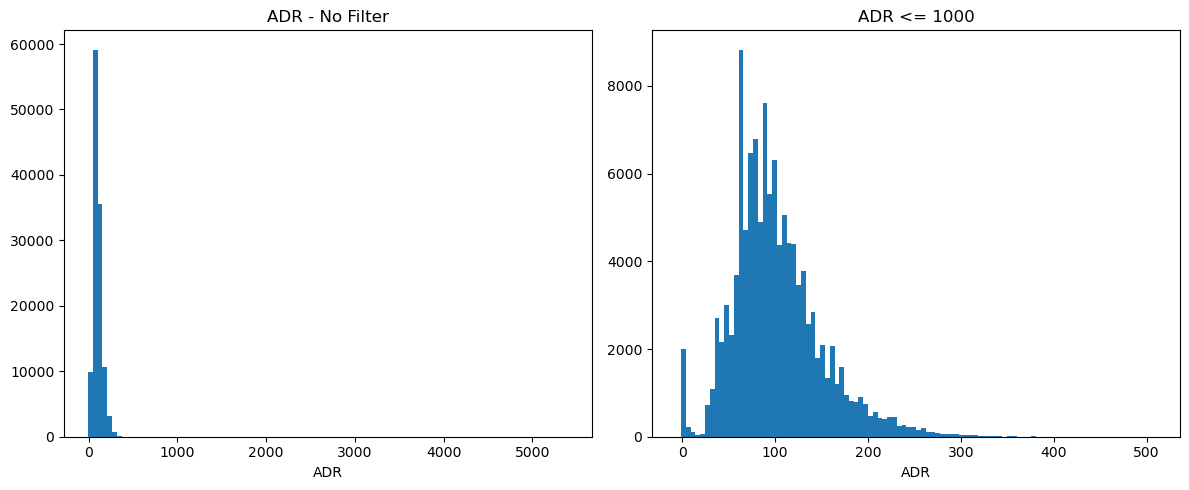

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df["adr"], bins=100)
axes[0].set_title("ADR - No Filter")
axes[0].set_xlabel("ADR")

axes[1].hist(df[(df["adr"] <= 1000)]["adr"], bins=100)
axes[1].set_title("ADR <= 1000")
axes[1].set_xlabel("ADR")

plt.tight_layout()

plt.savefig("images/section_03_histogram_01_adr.jpeg")
plt.show()

In [16]:
# ADR Corrections

df["adr"] = df["adr"].abs()
df["adr"] = df["adr"].clip(upper=500)

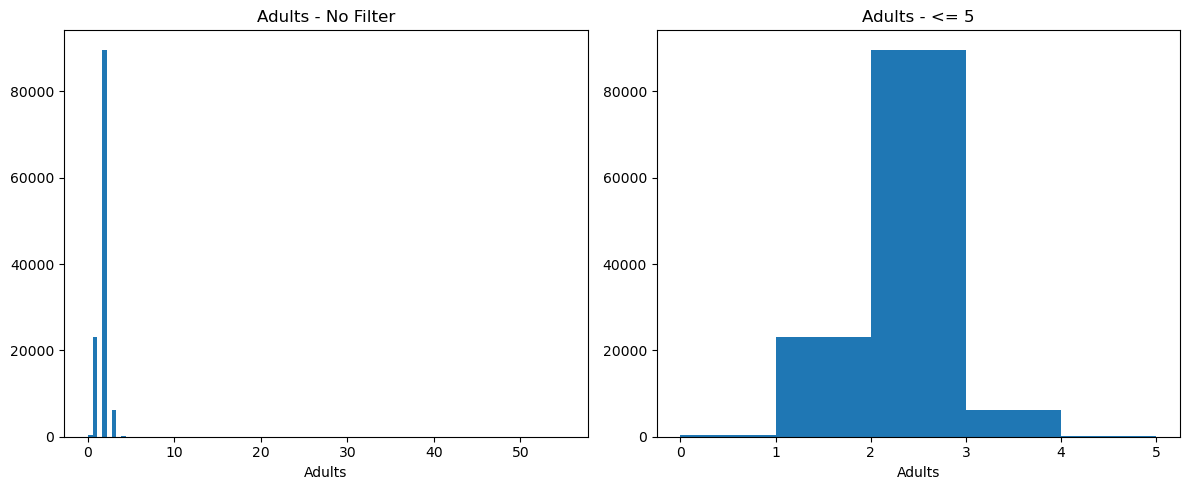

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df["adults"], bins=100)
axes[0].set_title("Adults - No Filter")
axes[0].set_xlabel("Adults")

axes[1].hist(df[(df["adults"] <= 5)]["adults"], bins=5)
axes[1].set_title("Adults - <= 5")
axes[1].set_xlabel("Adults")

plt.tight_layout()

plt.savefig("images/section_03_histogram_02_adults.jpeg")
plt.show()

In [18]:
mask = df["adults"] > 5
df = df[~mask].reset_index(drop=True)

mask = df["adults"] == 0
df = df[~mask].reset_index(drop=True)

### 3.5. Target Check

C:\Users\bruno.lima\AppData\Local\Temp\ipykernel_28232\3807671324.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  date=pd.to_datetime(


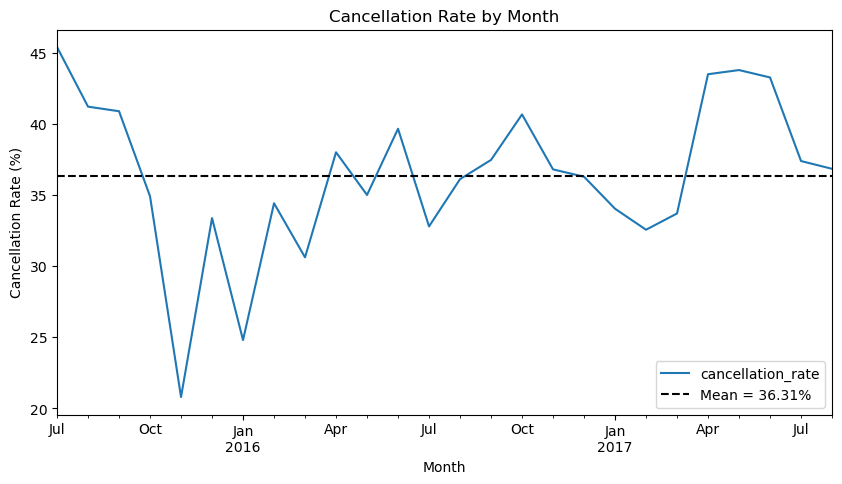

In [19]:
# Checking % cancelation by month:
# - There is some sazonality pherraps, but it is stable during the period
df_plot = (
    df.assign(
        date=pd.to_datetime(
            df["arrival_date_year"].astype(str) + "-" +
            df["arrival_date_month"] + "-01"
        )
    )
    .groupby("date")["is_canceled"]
    .mean()
    .mul(100)
    .reset_index(name="cancellation_rate")
)

df_plot.plot(
    x="date",
    y="cancellation_rate",
    figsize=(10, 5)
)

m = df_plot["cancellation_rate"].mean()
plt.axhline(
    m,
    linestyle="--",
    label=f"Mean = {m.round(2)}%",
    color="black"
)

plt.xlabel("Month")
plt.ylabel("Cancellation Rate (%)")
plt.title("Cancellation Rate by Month")
plt.legend()

plt.savefig("images/section_03_histogram_03_cancellation_rate.jpeg")
plt.show()

## 4. Spliting dataset

In [20]:
df["arrival_date"] = pd.to_datetime(df["arrival_date_year"].astype(str) + "-" + df["arrival_date_month"] + "-" + df["arrival_date_day_of_month"].astype(str))
df["booking_date"] = (df["arrival_date"] - pd.to_timedelta(df["lead_time"], unit="D"))

C:\Users\bruno.lima\AppData\Local\Temp\ipykernel_28232\955333115.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["arrival_date"] = pd.to_datetime(df["arrival_date_year"].astype(str) + "-" + df["arrival_date_month"] + "-" + df["arrival_date_day_of_month"].astype(str))


In [21]:
df["booking_date"].min()

Timestamp('2013-06-24 00:00:00')

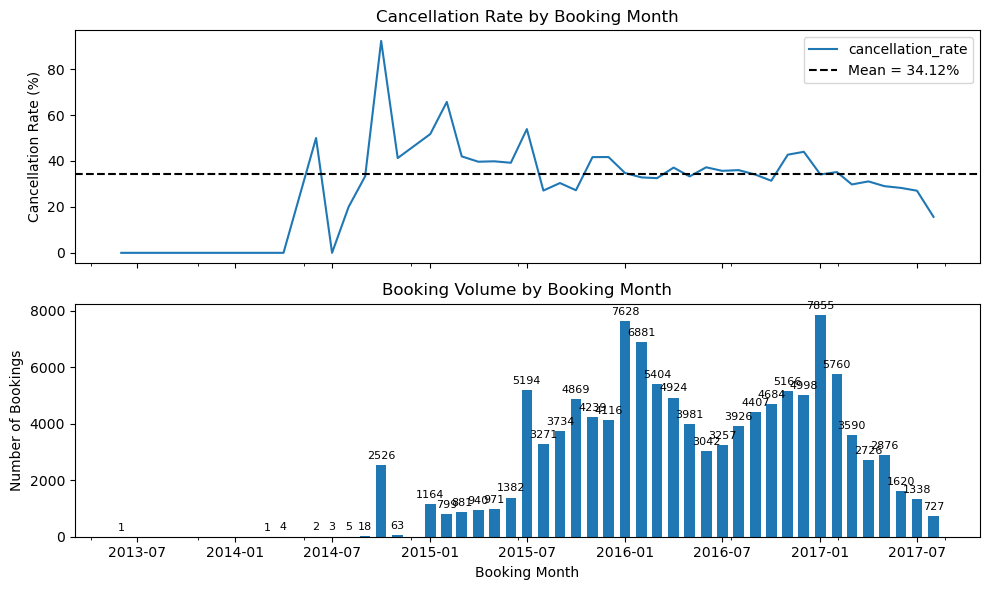

In [22]:
df_plot = (
    df.assign(
        date=df["booking_date"].dt.to_period("M").dt.to_timestamp()
    )
    .groupby("date")
    .agg(
        cancellation_rate=("is_canceled", "mean"),
        bookings=("is_canceled", "size")
    )
    .assign(cancellation_rate=lambda x: x["cancellation_rate"] * 100)
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

df_plot.plot(
    x="date",
    y="cancellation_rate",
    ax=axes[0],
    legend=False
)

m = df_plot["cancellation_rate"].mean()

axes[0].axhline(
    m,
    linestyle="--",
    color="black",
    label=f"Mean = {m.round(2)}%"
)

axes[0].set_xlabel("")
axes[0].set_ylabel("Cancellation Rate (%)")
axes[0].set_title("Cancellation Rate by Booking Month")
axes[0].legend()

bars = axes[1].bar(
    df_plot["date"],
    df_plot["bookings"],
    width=20
)

axes[1].bar_label(
    bars,
    fmt="%d",
    padding=3,
    fontsize=8
)

axes[1].set_xlabel("Booking Month")
axes[1].set_ylabel("Number of Bookings")
axes[1].set_title("Booking Volume by Booking Month")

plt.tight_layout()

plt.savefig("images/section_03_graph_04_booking_date_cancellation_volume.jpeg", dpi=300, bbox_inches="tight")

plt.show()

In [23]:
mask = df["booking_date"] < "2015-01-01"

print(f"Lines to remove: {mask.sum()}")
print(f"Cancelation rate (removed lines): {df[mask]["is_canceled"].mean():.4f}")
print(f"Cancelation rate (remain lines): {df[~mask]["is_canceled"].mean():.4f}")

Lines to remove: 2623
Cancelation rate (removed lines): 0.9016
Cancelation rate (remain lines): 0.3587


In [24]:
last_arrival = df["arrival_date"].max()

df["bd_month"] = df["booking_date"].dt.to_period("M")

recent = (
    df[df["bd_month"] >= "2017-01"].groupby("bd_month")
                                   .agg(
                                       lead_time_max_observado=("lead_time", "max"),
                                       lead_time_mediana=("lead_time", "median"),
                                       taxa_cancelamento=("is_canceled", "mean"),
                                       volume=("is_canceled", "size")
                                       )
                                    .round(3)
    )

recent

,lead_time_max_observado,lead_time_mediana,taxa_cancelamento,volume
bd_month,,,,
2017-01,241,77.0,0.341,7855
2017-02,211,60.0,0.352,5760
2017-03,181,47.0,0.298,3590
2017-04,151,31.0,0.311,2726
2017-05,119,26.0,0.290,2876
2017-06,87,19.0,0.283,1620
2017-07,60,14.0,0.271,1338
2017-08,30,3.0,0.157,727


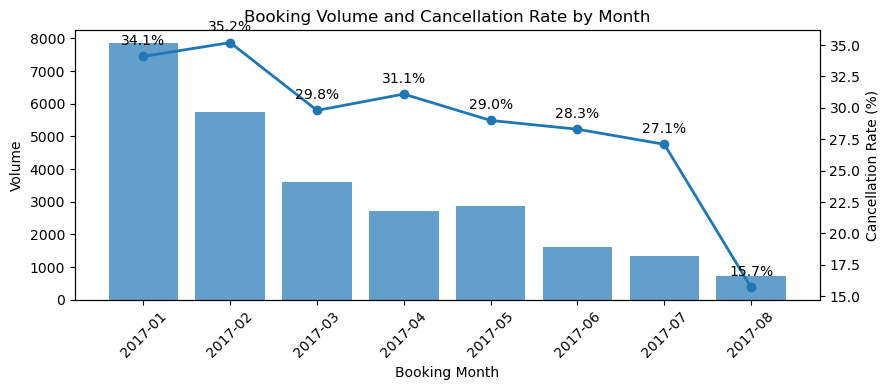

In [25]:
fig, ax1 = plt.subplots(figsize=(9, 4))

# Barras: volume
ax1.bar(
    recent.index.astype(str),
    recent["volume"],
    alpha=0.7,
    label="Volume"
)

ax1.set_xlabel("Booking Month")
ax1.set_ylabel("Volume")
ax1.tick_params(axis="x", rotation=45)

# Linha: taxa de cancelamento
ax2 = ax1.twinx()

ax2.plot(
    recent.index.astype(str),
    recent["taxa_cancelamento"] * 100,
    marker="o",
    linewidth=2,
    label="Cancellation Rate"
)

ax2.set_ylabel("Cancellation Rate (%)")

# Valores da taxa
for x, y in zip(range(len(recent)), recent["taxa_cancelamento"] * 100):
    ax2.annotate(
        f"{y:.1f}%",
        (x, y),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center"
    )


plt.title("Booking Volume and Cancellation Rate by Month")
plt.tight_layout()

plt.savefig("images/section_03_graph_05_booking_date_cancellation_volume_right.jpeg", dpi=300, bbox_inches="tight")

plt.show()

In [26]:
mask = df["booking_date"].between("2015-01-01", "2017-06-30")

df = df[mask].reset_index(drop=True)
print(f"Shape final = {df.shape}")

Shape final = (114285, 33)


In [27]:
last_arrival = df["arrival_date"].max()

df["bd_month"] = df["booking_date"].dt.to_period("M")

recent = (
    df.groupby("bd_month")
                        .agg(
                            taxa_cancelamento=("is_canceled", "mean"),
                            volume=("is_canceled", "size")
                            )
                        .round(3)
    )

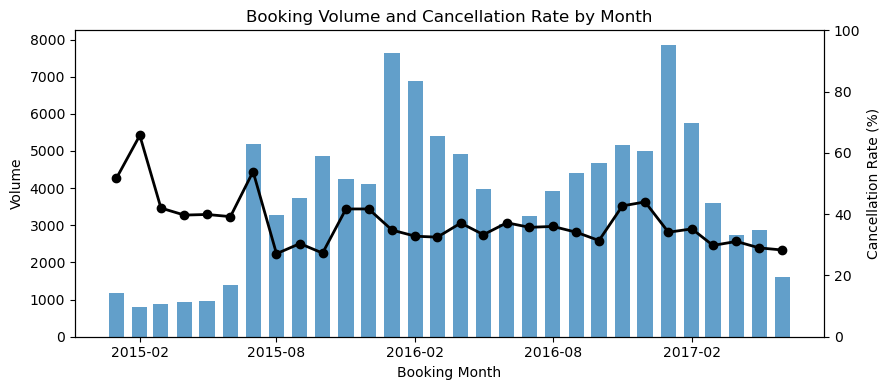

In [28]:
import matplotlib.dates as mdates

# Converter índice para datetime apenas para controlar o eixo X
x = recent.index.to_timestamp()

fig, ax1 = plt.subplots(figsize=(9, 4))

# Volume
bars = ax1.bar(
    x,
    recent["volume"],
    width=20,
    alpha=0.7
)

ax1.set_xlabel("Booking Month")
ax1.set_ylabel("Volume")

# Mostrar apenas a cada 6 meses
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax1.tick_params(axis="x")

# Taxa de cancelamento
ax2 = ax1.twinx()

ax2.plot(
    x,
    recent["taxa_cancelamento"] * 100,
    marker="o",
    linewidth=2,
    color="black"
)

ax2.set_ylabel("Cancellation Rate (%)")
ax2.set_ylim(0, 100)

plt.title("Booking Volume and Cancellation Rate by Month")
plt.tight_layout()

plt.savefig("images/section_03_graph_06_arrival_date_cancellation_final_volume.jpeg", dpi=300, bbox_inches="tight")

plt.show()

### 4.1 OOT

In [29]:
cutoff = "2017-01-01"
df_train = df[df["booking_date"] < cutoff].reset_index(drop=True)
df_test = df[df["booking_date"] >= cutoff].reset_index(drop=True)

print(f"Train = {df_train.shape} | {df_train["booking_date"].min().date()} -> {df_train["booking_date"].max().date()} | Cancelation Ratio = {df_train["is_canceled"].mean():.4f}")
print(f"Test  = {df_test.shape} | {df_test["booking_date"].min().date()} -> {df_test["booking_date"].max().date()} | Cancelation Ratio = {df_test["is_canceled"].mean():.4f}")
print()
print(f"Relative size Test dataset = {df_test.shape[0] / df.shape[0]:.4f}")

Train = (89858, 33) | 2015-01-01 -> 2016-12-31 | Cancelation Ratio = 0.3711
Test  = (24427, 33) | 2017-01-01 -> 2017-06-30 | Cancelation Ratio = 0.3241

Relative size Test dataset = 0.2137


In [30]:
df_train.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,arrival_date,booking_date,bd_month
0,resort_hotel,0,7,2015,july,27,1,0,1,1,...,no_agency,no_company,0,transient,75.0,0,0,2015-07-01,2015-06-24,2015-06
1,resort_hotel,0,13,2015,july,27,1,0,1,1,...,304.0,no_company,0,transient,75.0,0,0,2015-07-01,2015-06-18,2015-06
2,resort_hotel,0,14,2015,july,27,1,0,2,2,...,240.0,no_company,0,transient,98.0,0,1,2015-07-01,2015-06-17,2015-06
3,resort_hotel,0,14,2015,july,27,1,0,2,2,...,240.0,no_company,0,transient,98.0,0,1,2015-07-01,2015-06-17,2015-06
4,resort_hotel,0,0,2015,july,27,1,0,2,2,...,no_agency,no_company,0,transient,107.0,0,0,2015-07-01,2015-07-01,2015-07


### 4.2. TimeSeriesSplit x Train/Validation

In [31]:
df_train = df_train.sort_values(by="booking_date", ascending=True).reset_index(drop=True)

tscv = TimeSeriesSplit(n_splits=5)

In [32]:
for fold, (train_idx, val_idx) in enumerate(tscv.split(df_train)):
    print(f"Fold: {fold}")
    print(f"- train = {len(train_idx)}")
    print(f"{df_train.loc[train_idx, "booking_date"].min().date()} -> {df_train.loc[train_idx, "booking_date"].max().date()}")
    print(f"- validation = {len(val_idx)}")
    print(f"{df_train.loc[val_idx, "booking_date"].min().date()} -> {df_train.loc[val_idx, "booking_date"].max().date()}")

Fold: 0
- train = 14978
2015-01-01 -> 2015-09-03
- validation = 14976
2015-09-03 -> 2015-12-17
Fold: 1
- train = 29954
2015-01-01 -> 2015-12-17
- validation = 14976
2015-12-17 -> 2016-02-24
Fold: 2
- train = 44930
2015-01-01 -> 2016-02-24
- validation = 14976
2016-02-24 -> 2016-05-26
Fold: 3
- train = 59906
2015-01-01 -> 2016-05-26
- validation = 14976
2016-05-26 -> 2016-09-29
Fold: 4
- train = 74882
2015-01-01 -> 2016-09-29
- validation = 14976
2016-09-29 -> 2016-12-31


## 5. Exploratory Data Analysis (EDA)

In [33]:
target = "is_canceled"

y_train = df_train[target]
X_train = df_train.drop(columns=target)

y_test = df_test[target]
X_test = df_test.drop(columns=target)

In [34]:
numerical_columns = X_train.select_dtypes(include="number").columns.tolist()
categorical_columns = X_train.select_dtypes(include=["object", "category", "string"]).columns.tolist()

### 5.1. Univariate AUC & Information Value

In [35]:
resultados = []

for col in numerical_columns:
    valid = X_train[col].notna()
    auc = roc_auc_score(y_train[valid], X_train.loc[valid, col])
    forca = max(auc, 1-auc)
    resultados.append({
        "feature": col, 
        "auc_bruta": auc, 
        "forca": forca
        })

tabela_auc = pd.DataFrame(resultados).sort_values(by="forca", ascending=False).reset_index(drop=True)
tabela_auc

,feature,auc_bruta,forca
0,lead_time,0.677567,0.677567
1,total_of_special_requests,0.367938,0.632062
2,booking_changes,0.431872,0.568128
3,arrival_date_year,0.567504,0.567504
4,previous_cancellations,0.550443,0.550443
5,required_car_parking_spaces,0.450810,0.549190
6,adr,0.537155,0.537155
7,arrival_date_week_number,0.471575,0.528425
8,adults,0.523562,0.523562
9,days_in_waiting_list,0.523133,0.523133


In [36]:
def calculate_woe_iv(feature, target):
    df_temp = pd.DataFrame({"feature": feature, "target": target})

    agrupado = df_temp.groupby("feature")["target"].agg(
        eventos="sum",
        total="count"
    )
    agrupado["nao_eventos"] = agrupado["total"] - agrupado["eventos"]

    total_eventos = agrupado["eventos"].sum()
    total_nao_eventos = agrupado["nao_eventos"].sum()

    agrupado["pct_eventos"] = (agrupado["eventos"] + 0.5) / (total_eventos + 0.5)
    agrupado["pct_nao_eventos"] = (agrupado["nao_eventos"] + 0.5) / (total_nao_eventos + 0.5)

    agrupado["woe"] = np.log(agrupado["pct_eventos"] / agrupado["pct_nao_eventos"])
    agrupado["iv_parcial"] = (agrupado["pct_eventos"] - agrupado["pct_nao_eventos"]) * agrupado["woe"]

    iv_total = agrupado["iv_parcial"].sum()

    return agrupado, iv_total

In [37]:
resultados_iv = []
for col in categorical_columns:
    tabela_woe, iv = calculate_woe_iv(X_train[col], y_train)
    resultados_iv.append({
        "feature": col,
        "iv": iv,
        "n_categories": X_train[col].nunique()
    })

tabela_iv = pd.DataFrame(resultados_iv).sort_values(by="iv", ascending=False).reset_index(drop=True)
tabela_iv

,feature,iv,n_categories
0,deposit_type,2.041111,3
1,agent,0.788561,304
2,country,0.675002,166
3,market_segment,0.275557,8
4,assigned_room_type,0.230960,11
5,customer_type,0.182604,4
6,distribution_channel,0.130056,5
7,company,0.109466,303
8,hotel,0.077772,2
9,reserved_room_type,0.027520,9


### 5.1.1. Feature test selection

In [38]:
tabela_auc_padrao = tabela_auc.rename(columns={"forca": "power"})[["feature", "power"]]
tabela_auc_padrao["type"] = "numeric"

tabela_iv_padrao = tabela_iv.rename(columns={"iv": "power"})[["feature", "power"]]
tabela_iv_padrao["type"] = "categoric"

tabela_poder = pd.concat([tabela_auc_padrao, tabela_iv_padrao], ignore_index=True)
tabela_poder = tabela_poder.sort_values("power", ascending=False).reset_index(drop=True)

tabela_poder

,feature,power,type
0,deposit_type,2.041111,categoric
1,agent,0.788561,categoric
2,lead_time,0.677567,numeric
3,country,0.675002,categoric
4,total_of_special_requests,0.632062,numeric
5,booking_changes,0.568128,numeric
6,arrival_date_year,0.567504,numeric
7,previous_cancellations,0.550443,numeric
8,required_car_parking_spaces,0.549190,numeric
9,adr,0.537155,numeric


In [39]:
auc_power = 0.52
iv_power = 0.02

lista_features = tabela_poder[
    ((tabela_poder["type"] == "numeric") & (tabela_poder["power"] >= auc_power)) |
    ((tabela_poder["type"] == "categoric") & (tabela_poder["power"] >= iv_power))
]["feature"].tolist()

lista_features

['deposit_type',
 'agent',
 'lead_time',
 'country',
 'total_of_special_requests',
 'booking_changes',
 'arrival_date_year',
 'previous_cancellations',
 'required_car_parking_spaces',
 'adr',
 'arrival_date_week_number',
 'adults',
 'days_in_waiting_list',
 'stays_in_week_nights',
 'market_segment',
 'assigned_room_type',
 'customer_type',
 'distribution_channel',
 'company',
 'hotel',
 'reserved_room_type',
 'arrival_date_month']

In [40]:
# Checking deposit_type >> too high to be normal

pd.DataFrame({
    "quantity": y_train.groupby(X_train["deposit_type"]).size(),
    "cancellation_rate": y_train.groupby(X_train["deposit_type"]).mean().round(4)
})

,quantity,cancellation_rate
deposit_type,,
no_deposit,77985,0.2780
non_refund,11726,0.9928
refundable,147,0.1497


In [41]:
# Checking assigned_room_type x reserved_room_type

df.groupby(df["assigned_room_type"] == df["reserved_room_type"]).agg(
    cancellation_rate=("is_canceled", "mean"),
    quantity=("is_canceled", "size")
    )


,cancellation_rate,quantity
False,0.054119,14542
True,0.405773,99743


### 5.2. Decil Cut

In [42]:
def taxa_por_valor(feature, target):
    tabela = pd.DataFrame({
        "feature": feature,
        "is_canceled": target
    }).groupby(by="feature")["is_canceled"].agg(
        cancelation_rate="mean",
        quantity="count"
    )
    return tabela

lead_time (n_unique=475)


,cancelation_rate,quantity
lead_time_decile,,
"(-0.001, 3.0]",0.086367,9668
"(3.0, 13.0]",0.173374,8473
"(13.0, 31.0]",0.292002,9202
"(31.0, 50.0]",0.355527,8621
"(50.0, 76.0]",0.388258,9164
"(76.0, 108.0]",0.427452,8808
"(108.0, 151.0]",0.426521,9268
"(151.0, 197.0]",0.471189,8712
"(197.0, 270.0]",0.498554,8988


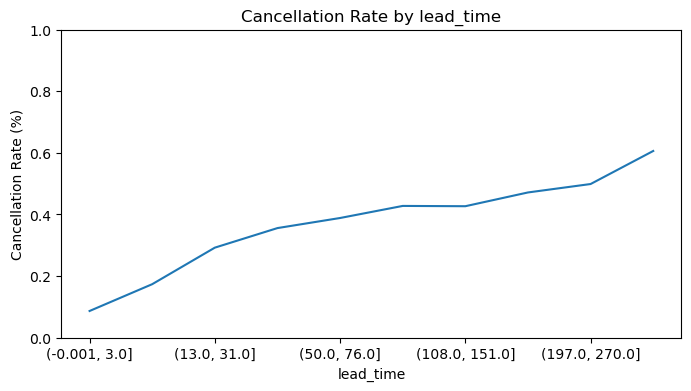


total_of_special_requests (n_unique=6)


,cancelation_rate,quantity
feature,,
0,0.474545,53900
1,0.211133,24397
2,0.232286,9639
3,0.207962,1683
4,0.115385,208
5,0.032258,31


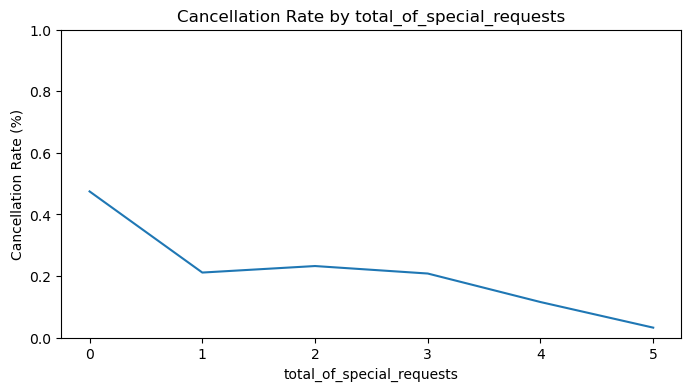


booking_changes (n_unique=18)


,cancelation_rate,quantity
feature,,
0,0.408756,76224
1,0.148927,9649
2,0.197806,2826
3,0.138848,677
4,0.192727,275
5,0.182796,93
6,0.277778,54
7,0.136364,22
8,0.363636,11


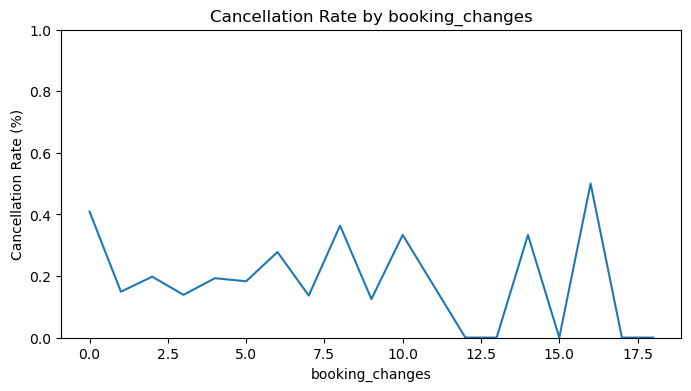


arrival_date_year (n_unique=3)


,cancelation_rate,quantity
feature,,
2015,0.298043,19316
2016,0.359013,56477
2017,0.519730,14065


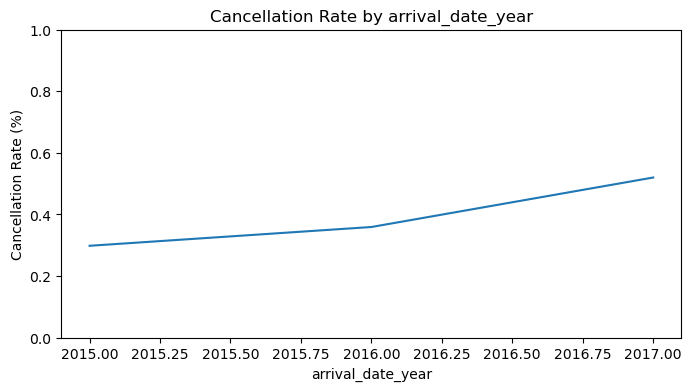


previous_cancellations (n_unique=14)


,cancelation_rate,quantity
feature,,
0,0.346406,85983
1,0.948965,3527
2,0.383562,73
3,0.300000,60
4,0.187500,16
5,0.153846,13
6,1.000000,7
11,0.285714,35
13,0.916667,12


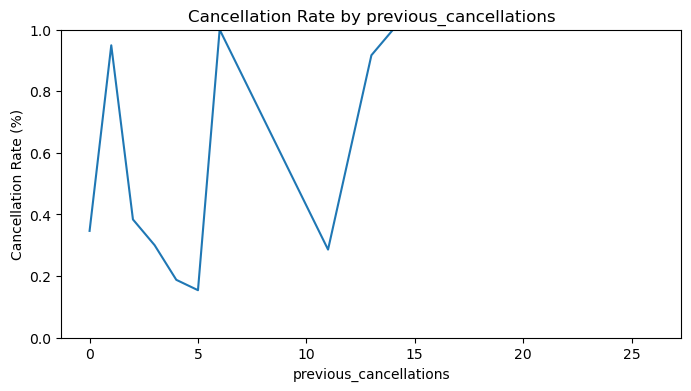


required_car_parking_spaces (n_unique=5)


,cancelation_rate,quantity
feature,,
0,0.395537,84298
1,0.000000,5539
2,0.000000,18
3,0.000000,2
8,0.000000,1


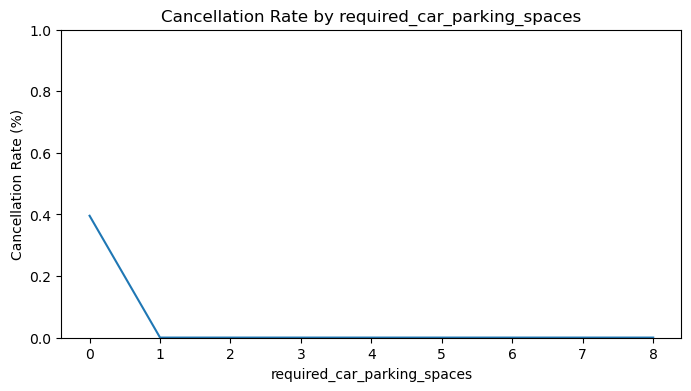


adr (n_unique=7603)


,cancelation_rate,quantity
adr_decile,,
"(-0.001, 48.5]",0.221085,8992
"(48.5, 62.9]",0.409934,8999
"(62.9, 73.0]",0.318322,9104
"(73.0, 80.75]",0.432354,8951
"(80.75, 90.0]",0.393589,9764
"(90.0, 100.0]",0.382532,9343
"(100.0, 110.7]",0.422017,7803
"(110.7, 126.0]",0.367283,8974
"(126.0, 151.2]",0.404315,8946


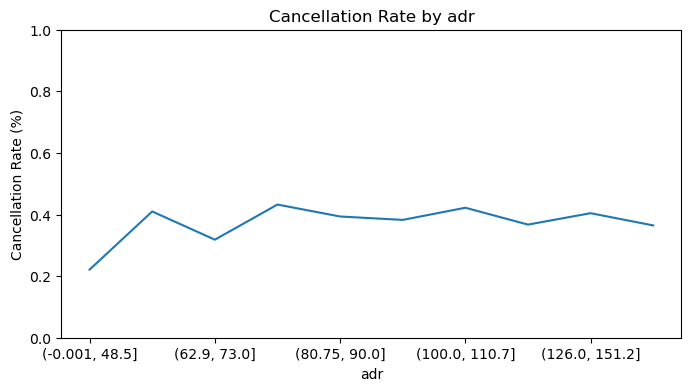


arrival_date_week_number (n_unique=53)


,cancelation_rate,quantity
arrival_date_week_number_decile,,
"(0.999, 9.0]",0.380285,9627
"(9.0, 15.0]",0.360391,9215
"(15.0, 20.0]",0.449269,8890
"(20.0, 25.0]",0.439564,8993
"(25.0, 30.0]",0.364305,8696
"(30.0, 35.0]",0.340021,9720
"(35.0, 39.0]",0.339867,8877
"(39.0, 43.0]",0.376311,9819
"(43.0, 47.0]",0.324837,7376


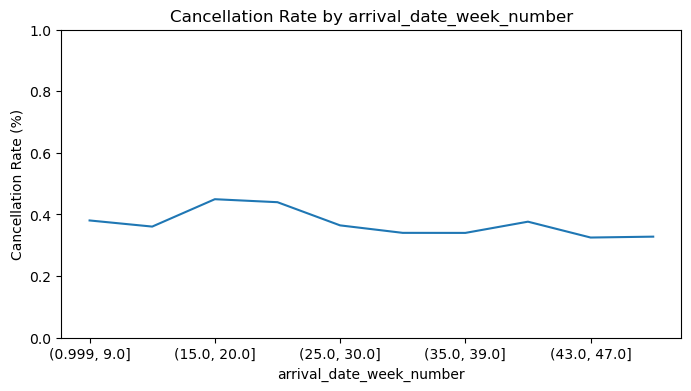


adults (n_unique=4)


,cancelation_rate,quantity
feature,,
1,0.302023,17353
2,0.391395,68220
3,0.327908,4239
4,0.239130,46


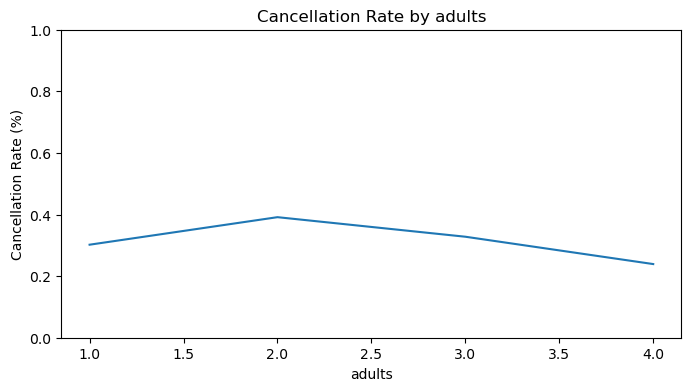


days_in_waiting_list (n_unique=125)


,cancelation_rate,quantity
days_in_waiting_list_decile,,
"(-0.001, 391.0]",0.371063,89858


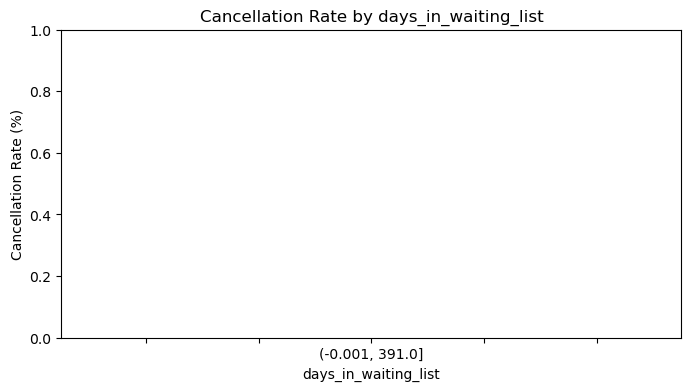


stays_in_week_nights (n_unique=32)


,cancelation_rate,quantity
stays_in_week_nights_decile,,
"(-0.001, 1.0]",0.309809,27914
"(1.0, 2.0]",0.442450,25352
"(2.0, 3.0]",0.384638,16873
"(3.0, 4.0]",0.358357,7180
"(4.0, 5.0]",0.349587,8593
"(5.0, 50.0]",0.357577,3946


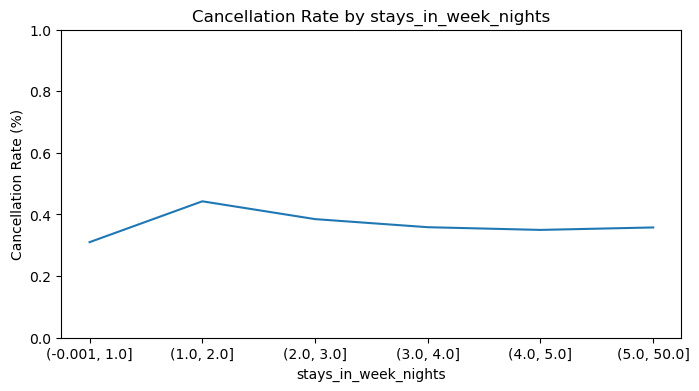

In [43]:
decile_cardinality_threshold = 20  # corte por julgamento, mesma categoria do auc_power/iv_power

numeric_features_final = [f for f in lista_features if f in numerical_columns]

for feature in numeric_features_final:
    n_unique = X_train[feature].nunique()

    if n_unique > decile_cardinality_threshold:
        decile_col = f"{feature}_decile"
        X_train[decile_col] = pd.qcut(X_train[feature], q=10, duplicates="drop")

        tabela = pd.DataFrame({
            decile_col: X_train[decile_col],
            "is_canceled": y_train
        }).groupby(decile_col, observed=True)["is_canceled"].agg(
            cancelation_rate="mean",
            quantity="count"
        )
    else:
        tabela = taxa_por_valor(X_train[feature], y_train)

    print(f"{feature} (n_unique={n_unique})")
    display(tabela)

    ax = tabela["cancelation_rate"].plot(kind="line", figsize=(8, 4))
    plt.xlabel(feature)
    plt.ylabel("Cancellation Rate (%)")
    plt.title(f"Cancellation Rate by {feature}")
    plt.ylim(0, 1)
    plt.show()
    print()

In [44]:
mask = X_train["previous_cancellations"] == 1

print(pd.crosstab(
    X_train.loc[mask, "deposit_type"],
    y_train[mask],
    normalize="index"
).round(4))

print()
print(X_train.loc[mask, "agent"].value_counts(normalize=True).head(10).round(4))

is_canceled        0       1
deposit_type                
no_deposit    0.1156  0.8844
non_refund    0.0000  1.0000

agent
no_agency    0.1358
1.0          0.1179
19.0         0.0964
9.0          0.0961
29.0         0.0513
37.0         0.0448
3.0          0.0388
240.0         0.036
96.0         0.0224
6.0          0.0221
Name: proportion, dtype: Float64


In [45]:
pd.crosstab(
    X_train["required_car_parking_spaces"] > 0,
    df_train["assigned_room_type"] == df_train["reserved_room_type"]
)

col_0,False,True
required_car_parking_spaces,,
False,10783,73515
True,1325,4235


In [46]:
mask = X_train["required_car_parking_spaces"] > 0

print(X_train.loc[mask, "market_segment"].value_counts(normalize=True).round(4))
print()
print(X_train.loc[mask, "distribution_channel"].value_counts(normalize=True).round(4))
print()
print(X_train.loc[mask, "customer_type"].value_counts(normalize=True).round(4))

market_segment
online_ta        0.5245
direct           0.2629
offline_ta/to    0.0827
corporate        0.0723
groups           0.0459
complementary    0.0106
aviation         0.0011
Name: proportion, dtype: float64

distribution_channel
ta/to        0.6236
direct       0.2878
corporate    0.0885
undefined    0.0002
Name: proportion, dtype: float64

customer_type
transient          0.8556
transient-party    0.1158
contract           0.0234
group              0.0052
Name: proportion, dtype: float64


In [47]:
# Investigando days_in_waiting_list: o decil quebrou porque a distribuição é
# extremamente concentrada em 0 -- tratando como variável quase-binária

X_train["was_on_waiting_list"] = X_train["days_in_waiting_list"] > 0

tabela_waiting = taxa_por_valor(X_train["was_on_waiting_list"], y_train)
tabela_waiting

,cancelation_rate,quantity
feature,,
False,0.359688,86197
True,0.638896,3661


### 5.3. Temporal Stability

In [48]:
X_train["booking_month"] = df_train["booking_date"].dt.to_period("M")

resultados_estabilidade = []

for feature in lista_features:
    is_numeric = feature in numerical_columns

    for month in X_train["booking_month"].unique():
        mask_month = X_train["booking_month"] == month
        y_mes = y_train[mask_month]
        x_mes = X_train.loc[mask_month, feature]

        if is_numeric:
            valid = x_mes.notna()
            if y_mes[valid].nunique() < 2:
                continue
            auc = roc_auc_score(y_mes[valid], x_mes[valid])
            poder = max(auc, 1 - auc)
        else:
            _, poder = calculate_woe_iv(x_mes, y_mes)

        resultados_estabilidade.append({
            "feature": feature,
            "month": month,
            "poder": poder,
            "quantidade": mask_month.sum()
        })

tabela_estabilidade = pd.DataFrame(resultados_estabilidade)
tabela_estabilidade["month"] = tabela_estabilidade["month"].astype(str)

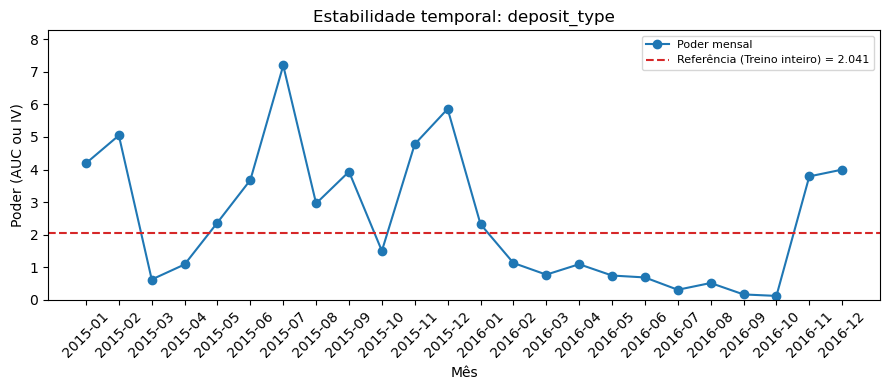

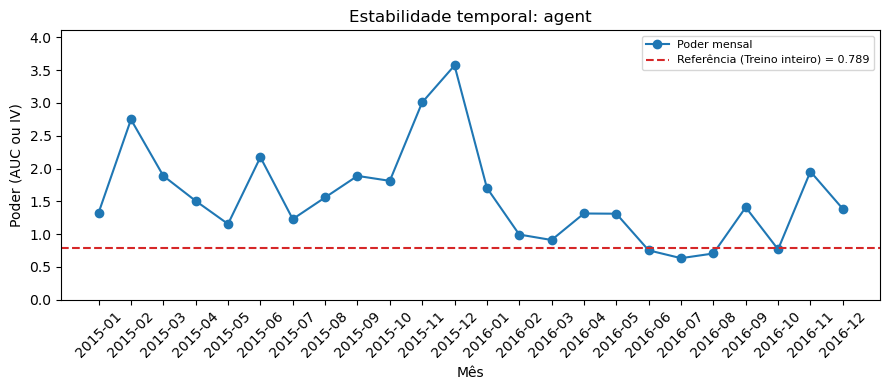

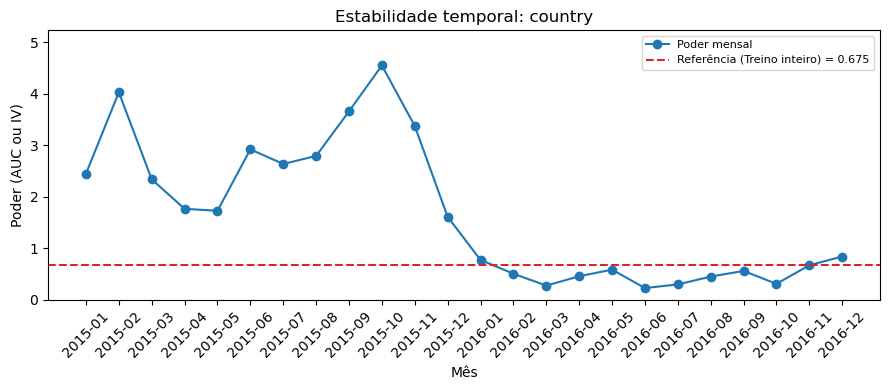

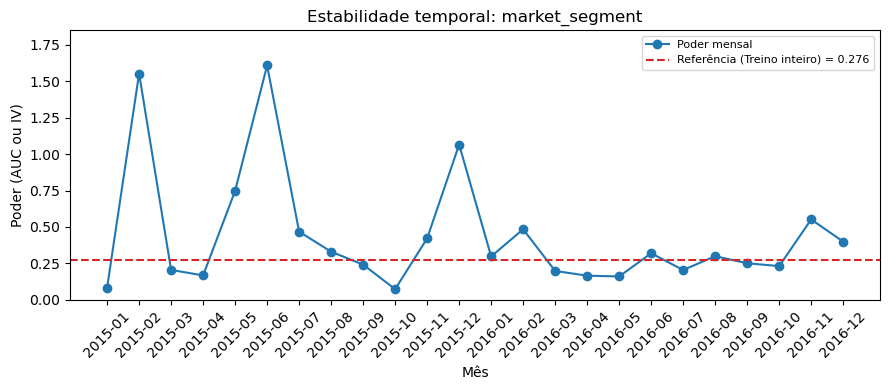

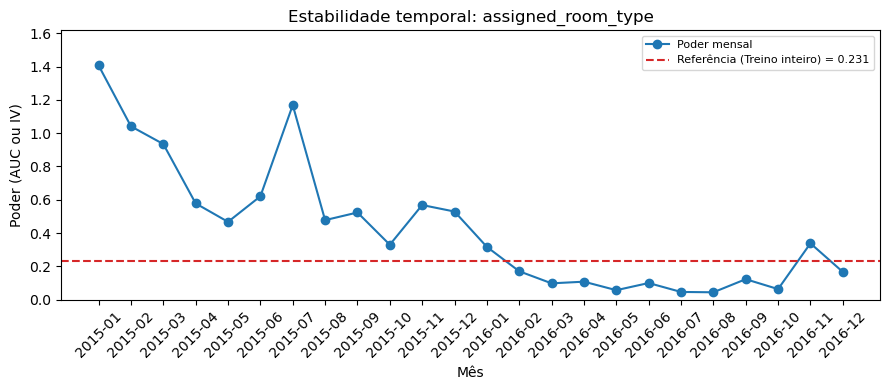

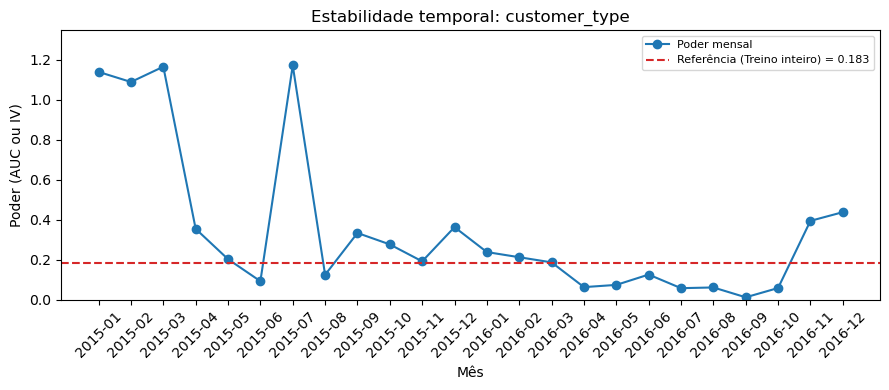

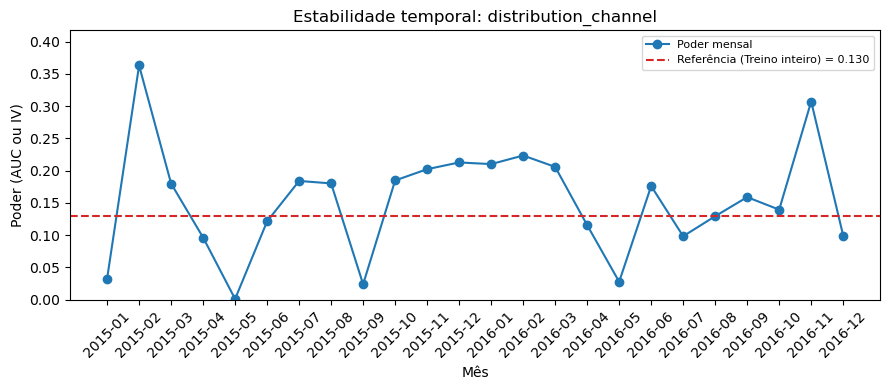

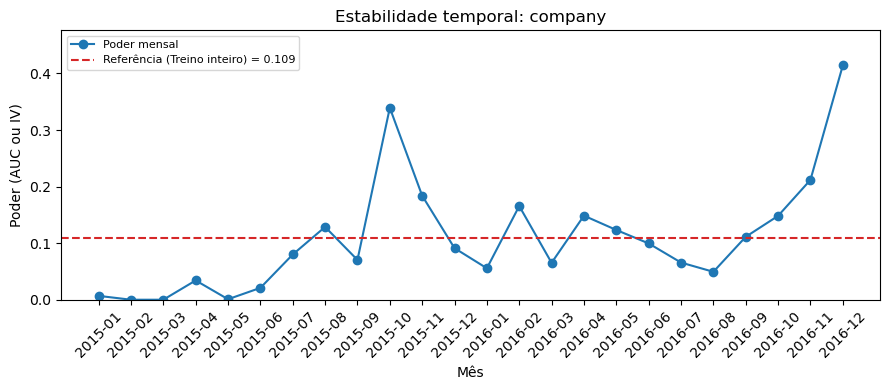

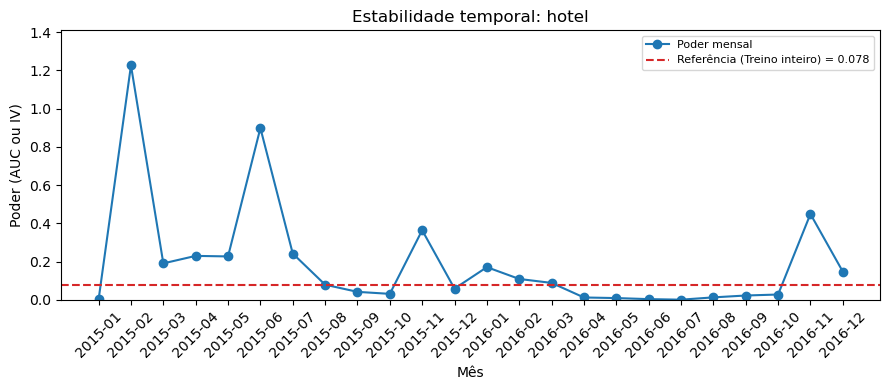

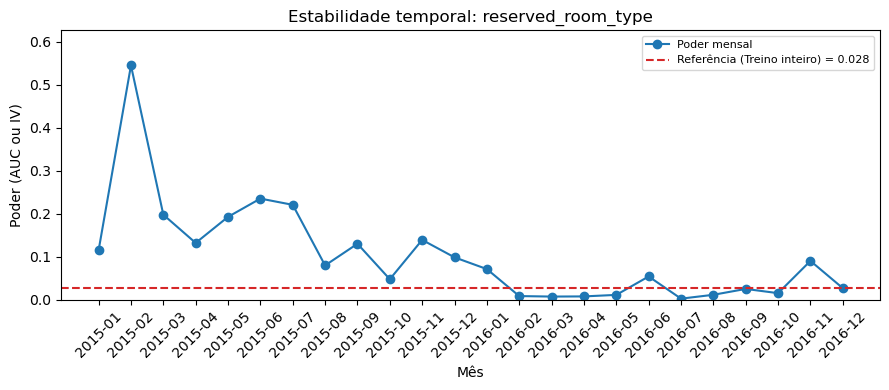

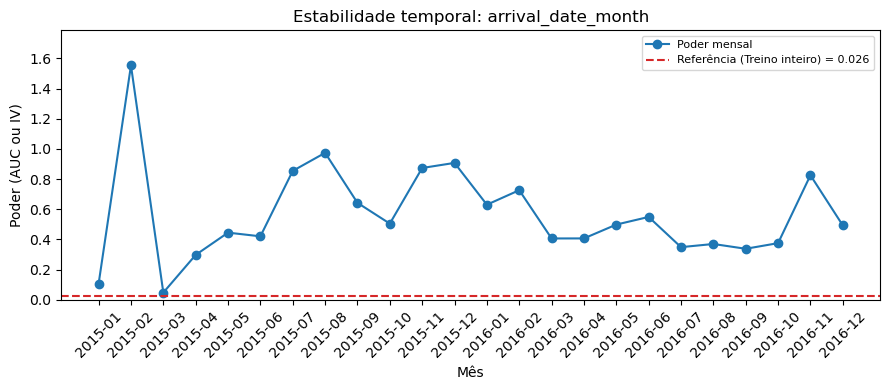

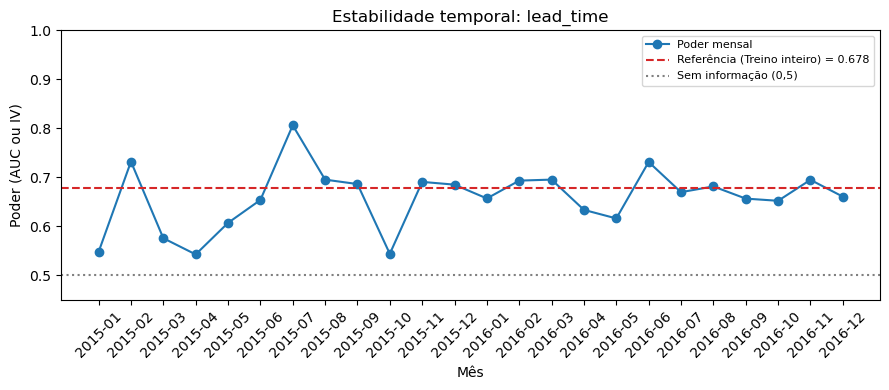

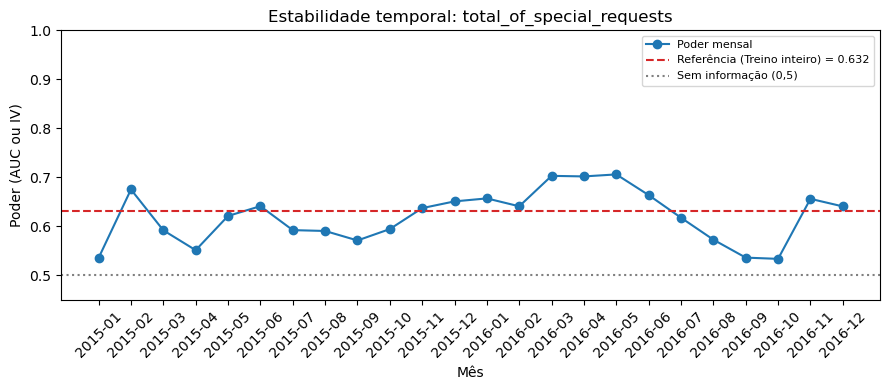

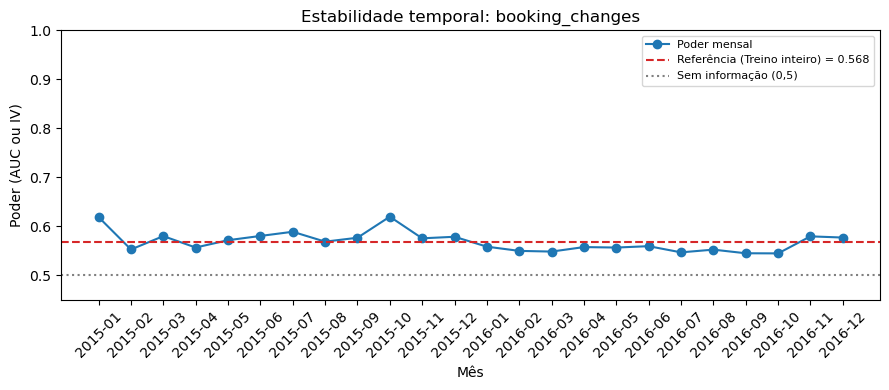

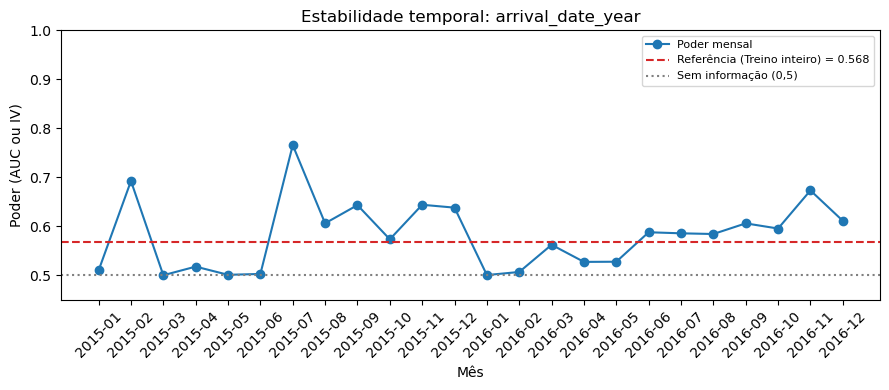

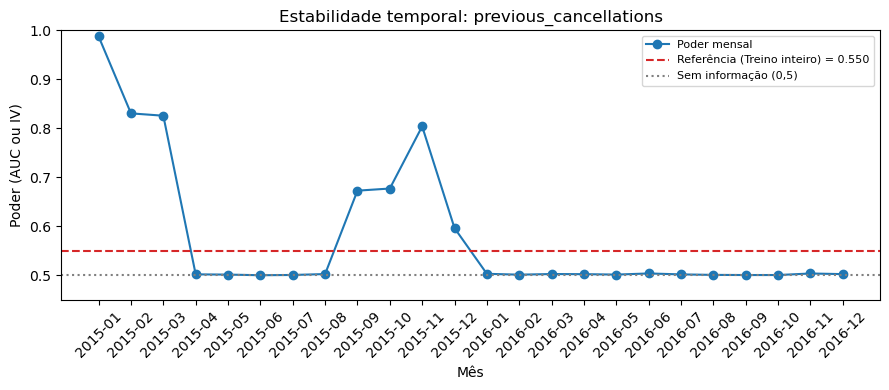

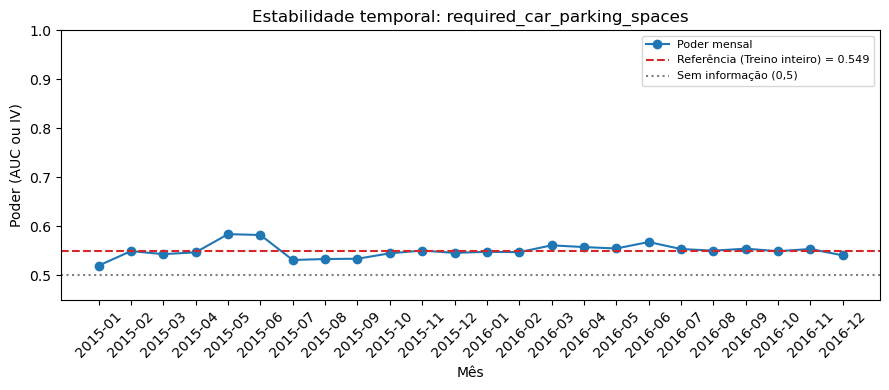

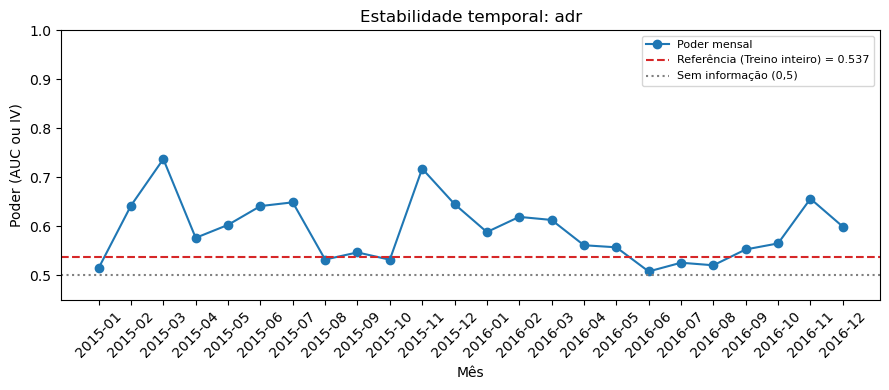

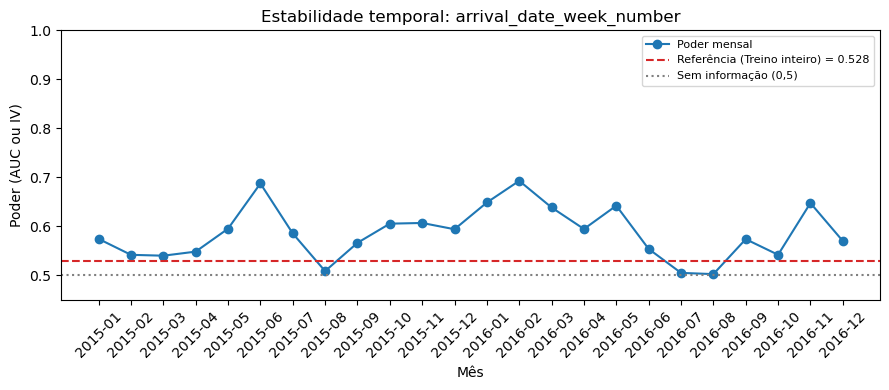

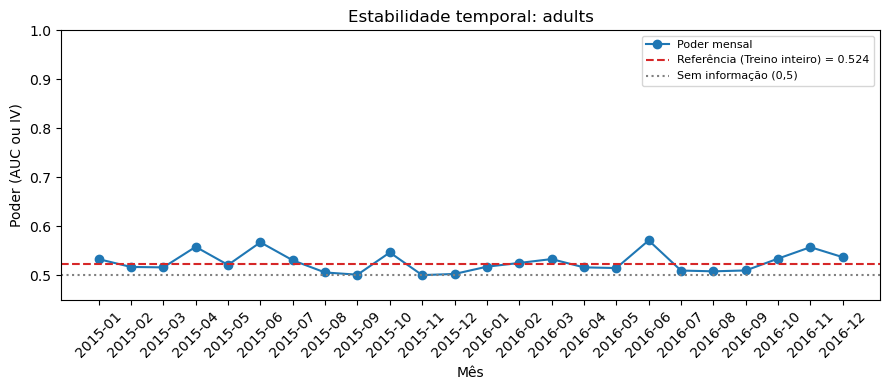

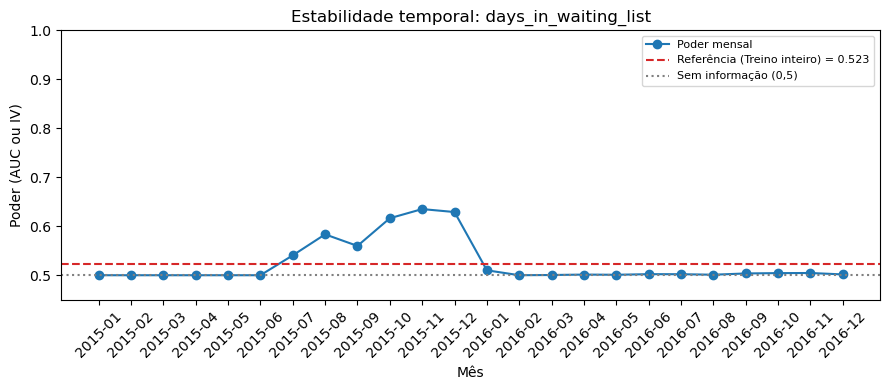

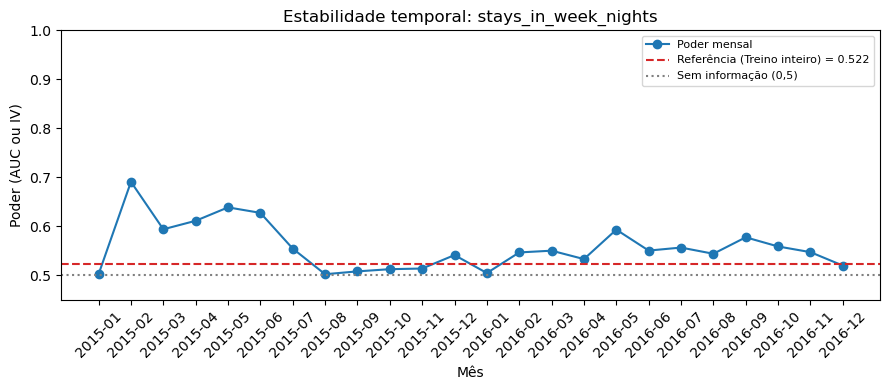

In [49]:
tipos_ordenados = ["categoric", "numeric"] 

for tipo in tipos_ordenados:
    features_do_tipo = tabela_poder[tabela_poder["type"] == tipo]["feature"].tolist()
    features_do_tipo = [f for f in features_do_tipo if f in tabela_estabilidade["feature"].unique()]

    for feature in features_do_tipo:
        dados = tabela_estabilidade[tabela_estabilidade["feature"] == feature]
        is_numeric = tipo == "numeric"

        referencia = tabela_poder.loc[tabela_poder["feature"] == feature, "power"].values[0]

        fig, ax1 = plt.subplots(figsize=(9, 4))
        ax1.plot(dados["month"], dados["poder"], marker="o", color="tab:blue", label="Poder mensal")
        ax1.axhline(referencia, color="tab:red", linestyle="--", label=f"Referência (Treino inteiro) = {referencia:.3f}")

        if is_numeric:
            ax1.set_ylim(0.45, 1.0)
            ax1.axhline(0.5, color="gray", linestyle=":", label="Sem informação (0,5)")
        else:
            teto = dados["poder"].max() * 1.15
            ax1.set_ylim(0, teto)

        ax1.set_ylabel("Poder (AUC ou IV)")
        ax1.set_xlabel("Mês")
        ax1.set_title(f"Estabilidade temporal: {feature}")
        ax1.legend(fontsize=8)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

In [50]:
tabela_deposito_mes = pd.DataFrame({
    "month": X_train["booking_month"],
    "deposit_type": X_train["deposit_type"],
    "is_canceled": y_train
})

taxa_non_refund_mes = (
    tabela_deposito_mes[tabela_deposito_mes["deposit_type"] == "non_refund"]
    .groupby("month")["is_canceled"]
    .agg(taxa="mean", quantidade="count")
)

taxa_non_refund_mes

,taxa,quantidade
month,,
2015-01,1.000000,345
2015-02,1.000000,370
2015-03,1.000000,46
2015-04,1.000000,72
2015-05,1.000000,141
2015-06,1.000000,269
2015-07,1.000000,2103
2015-08,1.000000,330
2015-09,1.000000,530


In [51]:
top_agents = X_train["agent"].value_counts().head(5).index.tolist()

tabela_agent_mes = pd.DataFrame({
    "month": X_train["booking_month"],
    "agent": X_train["agent"],
    "is_canceled": y_train
})

for agente in top_agents:
    print(f"Agent: {agente}")
    resultado = (
        tabela_agent_mes[tabela_agent_mes["agent"] == agente]
        .groupby("month")["is_canceled"]
        .agg(taxa="mean", quantidade="count")
    )
    display(resultado)

Agent: 9.0


,taxa,quantidade
month,,
2015-01,0.607143,56
2015-02,0.558140,43
2015-03,0.626667,75
2015-04,0.588235,68
2015-05,0.648148,54
2015-06,0.240000,25
2015-07,0.268293,41
2015-08,0.205479,730
2015-09,0.234727,622


Agent: no_agency


,taxa,quantidade
month,,
2015-01,0.582329,249
2015-02,0.000000,18
2015-03,0.066667,30
2015-04,0.111111,36
2015-05,0.460526,152
2015-06,0.314050,121
2015-07,0.116822,214
2015-08,0.194313,422
2015-09,0.320334,718


Agent: 240.0


,taxa,quantidade
month,,
2015-01,0.554054,74
2015-02,0.447761,67
2015-03,0.420000,100
2015-04,0.455172,145
2015-05,0.409774,266
2015-06,0.380711,394
2015-07,0.384615,403
2015-08,0.257329,307
2015-09,0.372671,322


Agent: 1.0


,taxa,quantidade
month,,
2015-01,1.000000,12
2015-02,0.936813,364
2015-03,0.439024,205
2015-04,0.375000,16
2015-05,0.903614,83
2015-06,0.881773,203
2015-07,0.708464,2552
2015-08,0.646341,82
2015-09,0.089844,256


Agent: 6.0


,taxa,quantidade
month,,
2015-01,0.717647,85
2015-02,0.750000,4
2015-03,0.206897,29
2015-04,0.200000,15
2015-05,0.242424,33
2015-06,0.500000,2
2015-07,0.515924,471
2015-08,0.694915,59
2015-09,0.392857,28


In [52]:
mask_prev1 = X_train["previous_cancellations"] == 1

volume_mensal = X_train.loc[mask_prev1, "booking_month"].value_counts().sort_index()
print(volume_mensal)

print()
print("Distribuição de agent dentro de previous_cancellations=1:")
print(X_train.loc[mask_prev1, "agent"].value_counts(normalize=True).head(5).round(3))

print()
mask_agent1 = X_train["agent"] == "1.0"
print("Distribuição de previous_cancellations dentro de agent=1.0:")
print(X_train.loc[mask_agent1, "previous_cancellations"].value_counts(normalize=True).head(5).round(3))

booking_month
2015-01     466
2015-02     317
2015-03     241
2015-04       3
2015-05       1
2015-07       3
2015-08       7
2015-09     402
2015-10     459
2015-11    1088
2015-12     347
2016-01      11
2016-02      17
2016-03      19
2016-04      22
2016-05      17
2016-06      26
2016-07       3
2016-08       4
2016-09      15
2016-10      18
2016-11      23
2016-12      18
Freq: M, Name: count, dtype: int64

Distribuição de agent dentro de previous_cancellations=1:
agent
no_agency    0.136
1.0          0.118
19.0         0.096
9.0          0.096
29.0         0.051
Name: proportion, dtype: Float64

Distribuição de previous_cancellations dentro de agent=1.0:
previous_cancellations
0    0.917
1    0.083
Name: proportion, dtype: float64


### 5.4. Adversarial Validation

In [53]:
# Target artificial: 0 = 2015 (início do Treino), 1 = 2016 (fim do Treino)
adversarial_target = (X_train["booking_month"].dt.year == 2016).astype(int)
features_calendario = ["arrival_date_year", "arrival_date_week_number"]

features_adversariais = [
    f for f in lista_features
    if f in numerical_columns and f not in features_calendario
]

X_adversarial = X_train[features_adversariais]

modelo_adversarial = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)

scores = cross_val_score(modelo_adversarial, X_adversarial, adversarial_target, cv=5, scoring="roc_auc")
print(f"AUC adversarial (média dos 5 folds): {scores.mean():.4f}")

AUC adversarial (média dos 5 folds): 0.6806


In [54]:
modelo_adversarial.fit(X_adversarial, adversarial_target)

importancias = pd.Series(
    modelo_adversarial.feature_importances_,
    index=features_adversariais
).sort_values(ascending=False)

importancias

previous_cancellations         0.292000
days_in_waiting_list           0.266070
adr                            0.205451
lead_time                      0.138659
total_of_special_requests      0.049105
adults                         0.022339
stays_in_week_nights           0.019955
required_car_parking_spaces    0.003601
booking_changes                0.002821
dtype: float64

In [55]:
mask_waiting = X_train["days_in_waiting_list"] > 0

volume_mensal_waiting = X_train.loc[mask_waiting, "booking_month"].value_counts().sort_index()

taxa_mensal_waiting = pd.DataFrame({
    "month": X_train["booking_month"],
    "is_canceled": y_train
})[mask_waiting].groupby("month")["is_canceled"].agg(taxa="mean", quantidade="count")
print(taxa_mensal_waiting)

             taxa  quantidade
month                        
2015-07  0.358643         619
2015-08  0.420472         635
2015-09  0.685484         248
2015-10  0.929825         342
2015-11  0.788860         772
2015-12  0.800000         700
2016-01  0.660714         112
2016-02  0.333333           9
2016-03  0.444444           9
2016-04  0.750000           8
2016-05  0.461538          13
2016-06  0.090909          11
2016-07  0.200000          20
2016-08  0.428571          28
2016-09  0.652174          23
2016-10  0.538462          39
2016-11  0.636364          55
2016-12  0.666667          18


### 5.5. Spearman Correlation

In [56]:
numeric_features_final = [f for f in lista_features if f in numerical_columns]

correlacao = X_train[numeric_features_final].corr(method="spearman")
correlacao.round(2)

,lead_time,total_of_special_requests,booking_changes,arrival_date_year,previous_cancellations,required_car_parking_spaces,adr,arrival_date_week_number,adults,days_in_waiting_list,stays_in_week_nights
lead_time,1.00,-0.05,0.01,0.34,0.06,-0.14,0.02,-0.04,0.18,0.17,0.29
total_of_special_requests,-0.05,1.00,0.04,0.07,-0.09,0.08,0.18,0.03,0.18,-0.14,0.09
booking_changes,0.01,0.04,1.00,0.01,-0.06,0.08,-0.01,0.01,-0.08,-0.02,0.07
arrival_date_year,0.34,0.07,0.01,1.00,-0.17,-0.05,0.09,-0.52,0.08,-0.03,0.06
previous_cancellations,0.06,-0.09,-0.06,-0.17,1.00,-0.04,-0.08,0.03,-0.06,0.16,-0.03
required_car_parking_spaces,-0.14,0.08,0.08,-0.05,-0.04,1.00,0.04,0.02,0.02,-0.05,-0.03
adr,0.02,0.18,-0.01,0.09,-0.08,0.04,1.00,0.04,0.27,-0.02,0.06
arrival_date_week_number,-0.04,0.03,0.01,-0.52,0.03,0.02,0.04,1.00,-0.02,-0.03,-0.01
adults,0.18,0.18,-0.08,0.08,-0.06,0.02,0.27,-0.02,1.00,-0.04,0.15
days_in_waiting_list,0.17,-0.14,-0.02,-0.03,0.16,-0.05,-0.02,-0.03,-0.04,1.00,0.01


In [57]:
X_vif = X_train[numeric_features_final].dropna()

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif_data.sort_values("VIF", ascending=False)

,feature,VIF
3,arrival_date_year,23.137357
8,adults,18.903080
6,adr,6.583928
7,arrival_date_week_number,5.310071
10,stays_in_week_nights,2.819767
0,lead_time,2.220150
1,total_of_special_requests,1.612407
2,booking_changes,1.136807
5,required_car_parking_spaces,1.093826
9,days_in_waiting_list,1.066716


### 5.6. Cramér's V Test

In [ ]:
def cramers_v(x, y):
    tabela_contingencia = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabela_contingencia)[0]
    n = tabela_contingencia.sum().sum()
    r, k = tabela_contingencia.shape
    df = min(r - 1, k - 1)
    v = (chi2 / (n * df)) ** 0.5
    limiar_grande_ajustado = 0.5 / (df ** 0.5)
    return v, df, limiar_grande_ajustado


piso_pratico = 0.5

resultados_cramer = []
for col1, col2 in combinations(categorical_columns, 2):
    v, df, limiar_ajustado = cramers_v(X_train[col1], X_train[col2])
    resultados_cramer.append({
        "feature_1": col1,
        "feature_2": col2,
        "cramers_v": v,
        "true_limiar": limiar_ajustado,
        "greater_true_limiar": v >= limiar_ajustado,
        "greater_pratical_limiar": v >= piso_pratico,
        "redundance": (v >= limiar_ajustado) and (v >= piso_pratico)
    })

tabela_cramer = pd.DataFrame(resultados_cramer).sort_values("cramers_v", ascending=False)
tabela_cramer[tabela_cramer["redundance"]]

,feature_1,feature_2,cramers_v,big_limiar,greater_true_limiar,greater_pratical_limiar,redundance
8,hotel,agent,0.879605,0.500000,True,True,True
51,reserved_room_type,assigned_room_type,0.724861,0.176777,True,True,True
48,distribution_channel,agent,0.715358,0.250000,True,True,True
38,market_segment,distribution_channel,0.683321,0.250000,True,True,True
42,market_segment,agent,0.634757,0.188982,True,True,True
43,market_segment,company,0.546158,0.188982,True,True,True
27,meal,agent,0.507866,0.250000,True,True,True


## 6. Feature Selection

In [75]:
drop_columns = {
    "assigned_room_type": "process leakage (Section 5.1.1) -- only exists after check-in",
    "arrival_date_year": "does not generalize (future years never seen in train) + contributed to inflated adversarial AUC (Section 5.4) + VIF=23.1 (Section 5.5)",
    "distribution_channel": "redundant with market_segment (Cramér's V=0.683, Section 5.6) -- market_segment has greater IV (0.276 vs 0.130)",
}

In [ ]:
numerical_columns_final = [
    f for f in lista_features
    if f in numerical_columns and f not in drop_columns
]

categorical_columns_final = [
    f for f in lista_features
    if f in categorical_columns and f not in drop_columns
]

print(f"Numeric final ({len(numerical_columns_final)}): {numerical_columns_final}")
print(f"Categorical final ({len(categorical_columns_final)}): {categorical_columns_final}")

Numeric final (10): ['lead_time', 'total_of_special_requests', 'booking_changes', 'previous_cancellations', 'required_car_parking_spaces', 'adr', 'arrival_date_week_number', 'adults', 'days_in_waiting_list', 'stays_in_week_nights']
Categorical final (9): ['deposit_type', 'agent', 'country', 'market_segment', 'customer_type', 'company', 'hotel', 'reserved_room_type', 'arrival_date_month']


In [83]:
features = numerical_columns_final + categorical_columns_final

X_train = X_train[features]
X_test = X_test[features]

((X_train.shape), (X_test.shape))

((89858, 19), (24427, 19))

## 7. Model Selection

### 7.1. Baseline Model

In [80]:
preprocessador_logreg = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numerical_columns_final),
    ("cat", OneHotEncoder(min_frequency=0.01, handle_unknown="infrequent_if_exist"), categorical_columns_final),
])

pipeline_logreg = Pipeline(steps=[
    ("preprocessamento", preprocessador_logreg),
    ("modelo", LogisticRegression(max_iter=1000, random_state=42)),
])


In [ ]:
metricas = ["roc_auc", "average_precision", "neg_log_loss"]

resultados_logreg = cross_validate(
    pipeline_logreg,
    X_train,
    y_train,
    cv=tscv,
    scoring=metricas,
    return_train_score=False
)

pd.DataFrame(resultados_logreg)

,fit_time,score_time,test_roc_auc,test_average_precision,test_neg_log_loss
0,0.216496,0.095305,0.960072,0.938673,-0.264124
1,0.387613,0.110384,0.818472,0.734552,-0.669981
2,0.613471,0.092331,0.835467,0.729720,-0.490298
3,0.757651,0.098830,0.836415,0.722233,-0.513321
4,1.057087,0.093224,0.877312,0.844465,-0.420318


In [87]:
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    val_dates = df_train.loc[val_idx, "booking_date"]
    subset = X_train.loc[val_idx]

    print(f"Fold {fold}: validação de {val_dates.min().date()} até {val_dates.max().date()}")
    print(f"  % non_refund (deposit_type): {(subset['deposit_type'] == 'non_refund').mean():.3f}")
    print(f"  % previous_cancellations==1: {(subset['previous_cancellations'] == 1).mean():.3f}")
    print(f"  % waiting_list>0: {(subset['days_in_waiting_list'] > 0).mean():.3f}")
    print()

Fold 0: validação de 2015-09-03 até 2015-12-17
  % non_refund (deposit_type): 0.194
  % previous_cancellations==1: 0.153
  % waiting_list>0: 0.115

Fold 1: validação de 2015-12-17 até 2016-02-24
  % non_refund (deposit_type): 0.110
  % previous_cancellations==1: 0.002
  % waiting_list>0: 0.026

Fold 2: validação de 2016-02-24 até 2016-05-26
  % non_refund (deposit_type): 0.068
  % previous_cancellations==1: 0.004
  % waiting_list>0: 0.002

Fold 3: validação de 2016-05-26 até 2016-09-29
  % non_refund (deposit_type): 0.025
  % previous_cancellations==1: 0.003
  % waiting_list>0: 0.005

Fold 4: validação de 2016-09-29 até 2016-12-31
  % non_refund (deposit_type): 0.138
  % previous_cancellations==1: 0.004
  % waiting_list>0: 0.008



In [88]:
print(resultados_logreg["test_roc_auc"])
print(f"Média: {resultados_logreg['test_roc_auc'].mean():.4f}")
print(f"Desvio-padrão: {resultados_logreg['test_roc_auc'].std():.4f}")

[0.96007189 0.8184716  0.83546676 0.83641504 0.87731247]
Média: 0.8655
Desvio-padrão: 0.0511


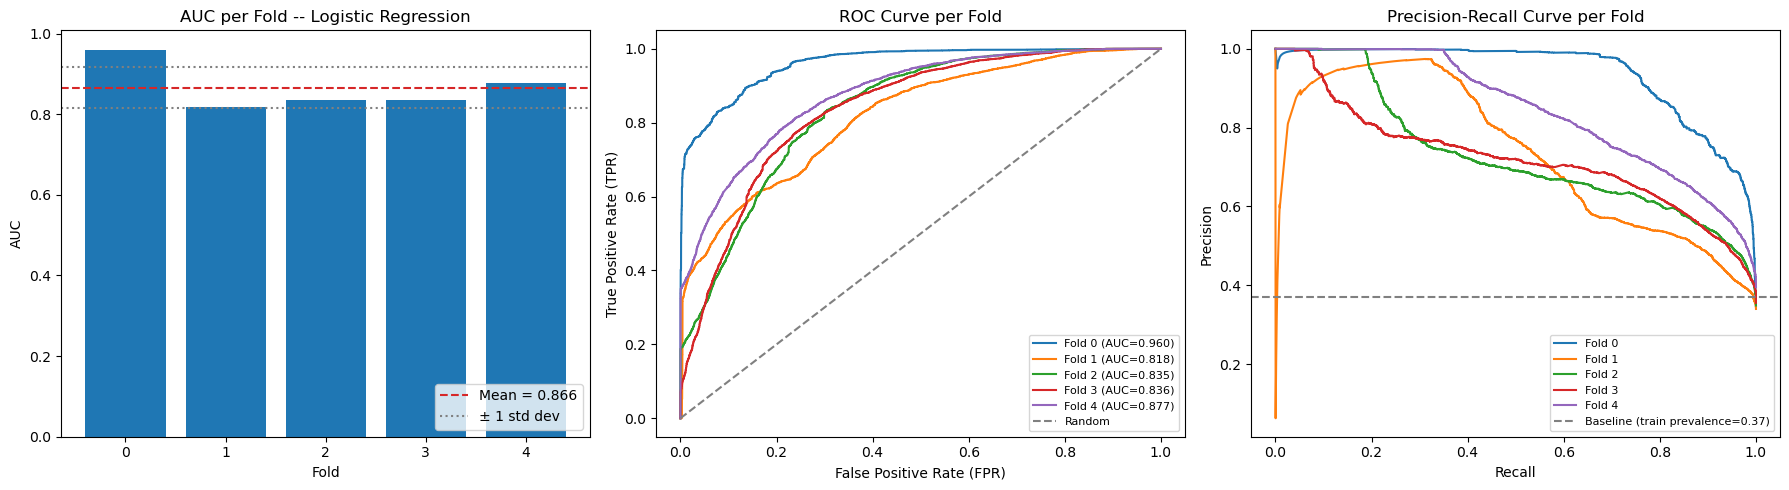

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

aucs_por_fold = resultados_logreg["test_roc_auc"]
media_auc = aucs_por_fold.mean()
desvio_auc = aucs_por_fold.std()

axes[0].bar(range(len(aucs_por_fold)), aucs_por_fold, color="tab:blue")
axes[0].axhline(media_auc, color="tab:red", linestyle="--", label=f"Mean = {media_auc:.3f}")
axes[0].axhline(media_auc - desvio_auc, color="gray", linestyle=":", label="± 1 std dev")
axes[0].axhline(media_auc + desvio_auc, color="gray", linestyle=":")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("AUC")
axes[0].set_title("AUC per Fold -- Logistic Regression")
axes[0].set_xticks(range(len(aucs_por_fold)))
axes[0].legend(loc="lower right")

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    pipeline_logreg.fit(X_tr, y_tr)
    probs = pipeline_logreg.predict_proba(X_val)[:, 1]

    fpr, tpr, _ = roc_curve(y_val, probs)
    axes[1].plot(fpr, tpr, label=f"Fold {fold} (AUC={auc(fpr, tpr):.3f})")

    precision, recall, _ = precision_recall_curve(y_val, probs)
    axes[2].plot(recall, precision, label=f"Fold {fold}")

axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random")
axes[1].set_xlabel("False Positive Rate (FPR)")
axes[1].set_ylabel("True Positive Rate (TPR)")
axes[1].set_title("ROC Curve per Fold")
axes[1].legend(fontsize=8, loc="lower right")

axes[2].axhline(y_train.mean(), color="gray", linestyle="--", label=f"Baseline (train prevalence={y_train.mean():.2f})")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve per Fold")
axes[2].legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig("images/section_07_graph_01_baseline_model_metrics.jpeg", dpi=300, bbox_inches="tight")
plt.show()

### 7.2. Model Comparation

In [115]:
class GBMCategoricalPreparer(BaseEstimator, TransformerMixin):
    def __init__(self, feature_columns, categorical_columns, fillna_label=None):
        self.feature_columns = feature_columns
        self.categorical_columns = categorical_columns
        self.fillna_label = fillna_label 

    def fit(self, X, y=None):
        self.categorias_ = {}
        for col in self.categorical_columns:
            self.categorias_[col] = X[col].astype("category").cat.categories
        return self

    def transform(self, X):
        X = X[self.feature_columns].copy()
        for col in self.categorical_columns:
            X[col] = pd.Categorical(X[col], categories=self.categorias_[col])
            if self.fillna_label is not None:
                X[col] = X[col].astype("object").fillna(self.fillna_label)
        return X

In [116]:
preprocessador_gbm = GBMCategoricalPreparer(
    feature_columns=features,
    categorical_columns=categorical_columns_final
)

preprocessador_gbm_catboost = GBMCategoricalPreparer(
    feature_columns=features,
    categorical_columns=categorical_columns_final,
    fillna_label="unseen"
)

pipeline_xgb = Pipeline(steps=[
    ("preprocessamento", preprocessador_gbm),
    ("modelo", XGBClassifier(enable_categorical=True, tree_method="hist", random_state=42)),
])

pipeline_lgbm = Pipeline(steps=[
    ("preprocessamento", preprocessador_gbm),
    ("modelo", LGBMClassifier(random_state=42, verbose=-1)),
])

pipeline_catboost = Pipeline(steps=[
    ("preprocessamento", preprocessador_gbm_catboost),
    ("modelo", CatBoostClassifier(cat_features=categorical_columns_final, random_state=42, verbose=0, allow_writing_files=False)),
])

In [117]:
def avaliar_pipeline_cv(pipeline, X, y, cv):
    resultados = {"test_roc_auc": [], "test_average_precision": [], "test_neg_log_loss": []}

    for train_idx, val_idx in cv.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        modelo_fold = copy.deepcopy(pipeline)
        modelo_fold.fit(X_tr, y_tr)
        probs = modelo_fold.predict_proba(X_val)[:, 1]

        resultados["test_roc_auc"].append(roc_auc_score(y_val, probs))
        resultados["test_average_precision"].append(average_precision_score(y_val, probs))
        resultados["test_neg_log_loss"].append(-log_loss(y_val, probs))

    return {k: np.array(v) for k, v in resultados.items()}

In [118]:
modelos = {
    "Logistic Regression": pipeline_logreg,
    "XGBoost": pipeline_xgb,
    "LightGBM": pipeline_lgbm,
    "CatBoost": pipeline_catboost,
}

metricas = ["roc_auc", "average_precision", "neg_log_loss"]

In [119]:
resultados_todos = {}

for nome, pipeline in modelos.items():
    resultado = avaliar_pipeline_cv(pipeline, X_train, y_train, tscv)
    resultados_todos[nome] = resultado

    media_auc = resultado["test_roc_auc"].mean()
    desvio_auc = resultado["test_roc_auc"].std()
    print(f"{nome}: AUC por fold = {resultado['test_roc_auc'].round(4)}")
    print(f"  Média={media_auc:.4f} | Desvio={desvio_auc:.4f}")
    print()

Logistic Regression: AUC por fold = [0.9601 0.8185 0.8355 0.8364 0.8773]
  Média=0.8655 | Desvio=0.0511

XGBoost: AUC por fold = [0.957  0.8606 0.8578 0.8482 0.9112]
  Média=0.8870 | Desvio=0.0413

LightGBM: AUC por fold = [0.9626 0.8767 0.8617 0.8633 0.9152]
  Média=0.8959 | Desvio=0.0385

CatBoost: AUC por fold = [0.9597 0.8921 0.8719 0.8629 0.9159]
  Média=0.9005 | Desvio=0.0348



### 7.3. t-Test of Nadeau-Bengio

In [ ]:
def nadeau_bengio_test(scores_a, scores_b, n_train_list, n_test_list):
    diffs = np.array(scores_a) - np.array(scores_b)
    k = len(diffs)
    mean_diff = diffs.mean()
    var_diff = diffs.var(ddof=1)

    n_train_mean = np.mean(n_train_list)
    n_test_mean = np.mean(n_test_list)
    correction = (1 / k) + (n_test_mean / n_train_mean)

    t_stat = mean_diff / np.sqrt(correction * var_diff)
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=k - 1))

    return mean_diff, t_stat, p_value

In [ ]:
n_train_list = []
n_test_list = []
for train_idx, val_idx in tscv.split(X_train):
    n_train_list.append(len(train_idx))
    n_test_list.append(len(val_idx))


pares_gbm = [
    ("CatBoost", "LightGBM"),
    ("CatBoost", "XGBoost"),
    ("LightGBM", "XGBoost"),
]

for modelo_a, modelo_b in pares_gbm:
    scores_a = resultados_todos[modelo_a]["test_roc_auc"]
    scores_b = resultados_todos[modelo_b]["test_roc_auc"]
    mean_diff, t_stat, p_value = nadeau_bengio_test(scores_a, scores_b, n_train_list, n_test_list)
    print(f"{modelo_a} vs {modelo_b}: diferença média = {mean_diff:+.4f} | t = {t_stat:.3f} | p = {p_value:.4f}")

CatBoost vs LightGBM: diferença média = +0.0046 | t = 0.809 | p = 0.4641
CatBoost vs XGBoost: diferença média = +0.0135 | t = 1.624 | p = 0.1797
LightGBM vs XGBoost: diferença média = +0.0089 | t = 1.978 | p = 0.1190


## 8. Model Tuning

In [124]:
def objetivo(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth": trial.suggest_int("depth", 3, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True),
        "iterations": 1000,
        "cat_features": categorical_columns_final,
        "random_state": 42,
        "verbose": 0,
        "allow_writing_files": False,
    }

    log_losses = []
    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        X_tr_prep = preprocessador_gbm_catboost.fit_transform(X_tr)
        X_val_prep = preprocessador_gbm_catboost.transform(X_val)

        modelo = CatBoostClassifier(**params)
        modelo.fit(X_tr_prep, y_tr, eval_set=(X_val_prep, y_val), early_stopping_rounds=50, verbose=0)

        probs = modelo.predict_proba(X_val_prep)[:, 1]
        log_losses.append(log_loss(y_val, probs))

    return np.mean(log_losses)

In [ ]:
# study = optuna.create_study(direction="minimize")
# study.optimize(objetivo, n_trials=30)

# print("Melhores hiperparâmetros:", study.best_params)
# print("Melhor log loss médio:", study.best_value)

[I 2026-10-01 14:03:24,969] A new study created in memory with name: no-name-38c8856a-e835-4fec-9e0e-491fc9310407
[I 2026-10-01 14:04:51,929] Trial 0 finished with value: 0.386031387548023 and parameters: {'learning_rate': 0.2891057182046895, 'depth': 8, 'l2_leaf_reg': 3.527863746415757}. Best is trial 0 with value: 0.386031387548023.
[I 2026-10-01 14:10:09,188] Trial 1 finished with value: 0.3967511020241503 and parameters: {'learning_rate': 0.015656709125426705, 'depth': 3, 'l2_leaf_reg': 1.5887340240770509}. Best is trial 0 with value: 0.386031387548023.
[I 2026-10-01 14:12:15,021] Trial 2 finished with value: 0.38115407066071777 and parameters: {'learning_rate': 0.10633437284625621, 'depth': 7, 'l2_leaf_reg': 7.182767066173723}. Best is trial 2 with value: 0.38115407066071777.
[I 2026-10-01 14:14:26,090] Trial 3 finished with value: 0.38857289692464875 and parameters: {'learning_rate': 0.06978595946089644, 'depth': 7, 'l2_leaf_reg': 2.0851700817142027}. Best is trial 2 with value: 

Melhores hiperparâmetros: {'learning_rate': 0.09434700010568219, 'depth': 7, 'l2_leaf_reg': 2.856236544950036}
Melhor log loss médio: 0.37344392611466687


In [ ]:
# joblib.dump(study, "./artifacts/optuna/optuna_study_catboost_v1.pkl")

# study.best_params

{'learning_rate': 0.09434700010568219,
 'depth': 7,
 'l2_leaf_reg': 2.856236544950036}

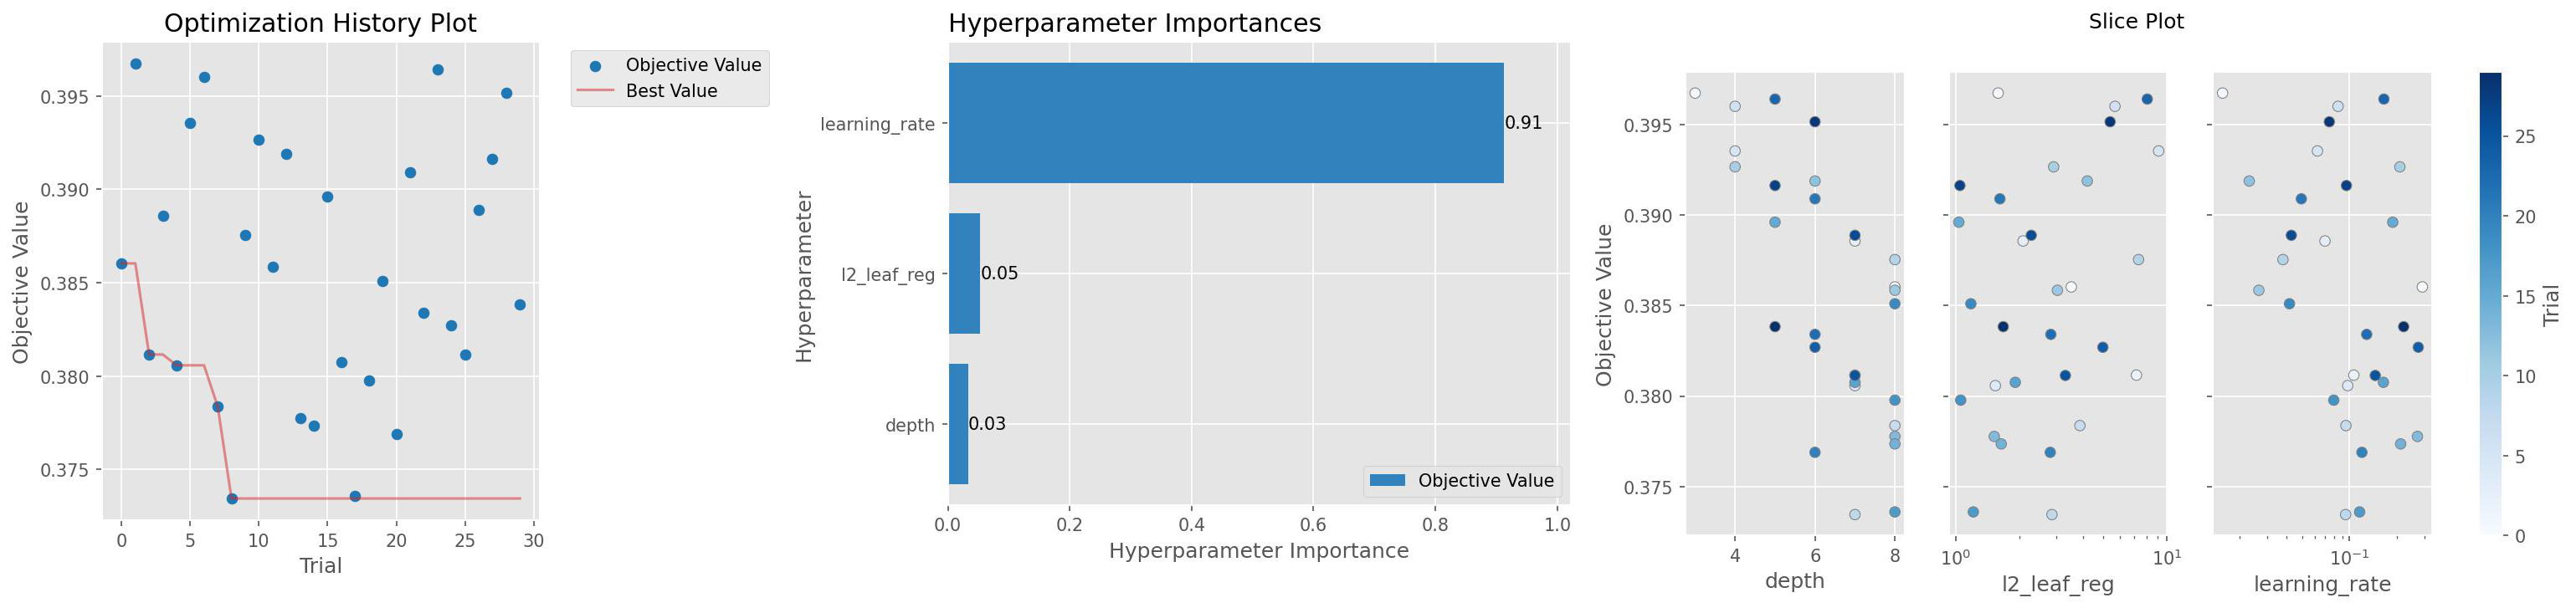

In [150]:
study = joblib.load("artifacts/optuna/optuna_study_catboost_v1.pkl")

os.makedirs("images", exist_ok=True)

oviz.plot_optimization_history(study)
plt.savefig(f"images/_temp_history.jpeg", bbox_inches="tight", dpi=150)
plt.close()

oviz.plot_param_importances(study)
plt.savefig(f"images/_temp_importances.jpeg", bbox_inches="tight", dpi=150)
plt.close()

oviz.plot_slice(study, params=["learning_rate", "depth", "l2_leaf_reg"])
plt.savefig(f"images/_temp_slice.jpeg", bbox_inches="tight", dpi=150)
plt.close()

imgs = [Image.open(f"images/_temp_{name}.jpeg") for name in ["history", "importances", "slice"]]
total_width = sum(img.width for img in imgs)
max_height = max(img.height for img in imgs)

combined = Image.new("RGB", (total_width, max_height), "white")
x_offset = 0
for img in imgs:
    combined.paste(img, (x_offset, 0))
    x_offset += img.width

combined.save(f"images/section_08_graph_optuna_resultados_catboost_tuning.jpeg")

for name in ["history", "importances", "slice"]:
    os.remove(f"images/_temp_{name}.jpeg")

combined

In [ ]:
best_params = {
    "learning_rate": 0.09434700010568219,
    "depth": 7,
    "l2_leaf_reg": 2.856236544950036,
}